## Import data

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [104]:
from xint_toolbox import piv_lab_rearrange, divergence
from xint_toolbox import nematic_order_filter, nematic_order_of_full_image, nematic_to_vector
from xint_toolbox import sec_to_min_and_sec, create_folder, find_closest

In [105]:
import warnings
warnings.filterwarnings("ignore")

import nd2, tifffile

def find_closest_two(arr, x):
    idx = np.argsort(np.abs(arr - x))[:2]
    return arr[idx], idx

In [106]:
data_info = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'actin_highres')
data_info = data_info[data_info.cortex_flow_analysis.isin(['wt', 'carhoa'])] 

staging_cols = ["m1", "ck1", "df1", "afz1", "pfa1", "m2", 'septum1', "ck2", "start", "stop"]
data_info[staging_cols] = data_info[staging_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")

wt_data_info = data_info[data_info.cortex_flow_analysis.isin(['wt'])].reset_index()
carhoa_data_info = data_info[data_info.cortex_flow_analysis.isin(['carhoa'])].reset_index()

In [107]:
carhoa_data_info

,index,rep_name,experiment,folder,file_name,embryo,raw_data,movie_name,pivlabtxt_folder,objective,...,stop,vmin,vmax,cortex_flow_analysis,no_quanti,transitional_phase_CB_width,cb_width,afz_width,pro_rotate_for_edge,deal_with_edge
0,54,rep56,NaN,carhoa,xin240816,e45,NaN,rep56_roi4.tif,NaN,NaN,...,100,250.0,1700.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
1,65,rep67,NaN,carhoa,xin240802_csu3_utregfp_carhoa600nginj,e22,NaN,rep67_roi4.tif,NaN,NaN,...,200,250.0,4000.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
2,66,rep68,NaN,carhoa,xin240802_csu3_utregfp_carhoa600nginj,e23,NaN,rep68_roi4.tif,NaN,NaN,...,180,200.0,2000.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
3,70,rep72,NaN,carhoa,xin240725_csu1_lifeact_carhoa600pginj,e022,NaN,rep72_roi4.tif,NaN,NaN,...,120,250.0,2800.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
4,74,rep76,NaN,carhoa,xin240724_csu3_utregfp_carhoa600nginj,e017,NaN,rep76_roi4.tif,NaN,NaN,...,165,450.0,2400.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
5,75,rep77,NaN,carhoa,xin240724_csu3_utregfp_carhoa600nginj,e018,NaN,rep77_roi4.tif,max_proj,shadowy,...,100,200.0,1700.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
6,78,rep80,NaN,carhoa,xin240723_csu3_utregfp_carhoa600nginj,e015,NaN,rep80_roi4.tif,max_proj,NaN,...,150,250.0,1500.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
7,79,rep81,NaN,carhoa,xin240723_csu3_utregfp_carhoa600nginj,e016,NaN,rep81_roi4.tif,max_proj,NaN,...,200,300.0,2000.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
8,80,rep82,NaN,carhoa,xin240710_csu3_utregfp_carhoa600ng_e1,e12,NaN,rep82_roi4.tif,max_proj,not too much phenotype,...,75,130.0,2900.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN
9,81,rep83,NaN,carhoa,xin240710_csu3_utregfp_carhoa600ng_e1,e13,NaN,rep83_roi4.tif,max_proj,GOOD,...,200,150.0,1200.0,carhoa,carhoa600,NaN,NaN,NaN,NaN,NaN


## Processing

### Wild-type

In [108]:
# wt_images_for_adz_manual_measurement = []
# for i in wt_data_info.index:
#     replicate = wt_data_info.loc[i]
#     print(replicate.rep_name)
#     file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
#     time_interval = replicate.time_interval
#     frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))

#     image_frame_47p5mpf = tifffile.TiffFile(file_name).series[0].asarray(key=frame_47p5mpf)
    
#     wt_images_for_adz_manual_measurement.append(image_frame_47p5mpf)
#     fig, ax = plt.subplots(figsize=[1.5, 1.5])
#     ax.imshow(image_frame_47p5mpf, cmap='inferno')
#     plt.show()

# skimage.io.imsave('wt//wt_images_for_adz_manual_measurement.tif', np.array(wt_images_for_adz_manual_measurement).astype(np.int16))

In [109]:
wt_images_for_adz_manual_measurement_data = pd.read_csv('wt//wt_images_for_adz_manual_measurement.csv')
wt_images_for_adz_manual_measurement_data_2 = pd.read_csv('wt//wt_images_for_furrow_position_manual_label.csv')

In [110]:
# adz width
for i in wt_data_info.index[:]:
    replicate = wt_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = wt_images_for_adz_manual_measurement_data[wt_images_for_adz_manual_measurement_data['Slice'] == i+1]
    adz_width = np.mean(a['Height']) * pixel_size
    wt_data_info.loc[i, 'adz_width'] = adz_width

rep1
rep2
rep3
rep4
rep5
rep6
rep7
rep8
rep9
rep10


In [111]:
# cable qxx
for i in wt_data_info.index:
    replicate = wt_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = wt_images_for_adz_manual_measurement_data_2[wt_images_for_adz_manual_measurement_data_2['Slice'] == i+1].iloc[0]
    cabel_roi_x0, cable_roi_y0 = round(a['X'] - a['Width']/2), round(a['Y'] - a['Height']/2)
    cabel_roi_width, cabel_roi_height = a['Width'], a['Height']

    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    image_frame_47p5mpf = tifffile.TiffFile(file_name).series[0].asarray(key=frame_47p5mpf)
    image_frame_47p5mpf_q = nematic_order_of_full_image(image_frame_47p5mpf, windowsize=int(30/30*40), qmin=1/30*40, qmax=15/30*40, print_minmax=False)
    image_frame_47p5mpf_qx, image_frame_47p5mpf_qy, image_frame_47p5mpf_qxx, image_frame_47p5mpf_qxy = image_frame_47p5mpf_q

    mask = (image_frame_47p5mpf_qx >= cabel_roi_x0) & (image_frame_47p5mpf_qx <= cabel_roi_x0 + cabel_roi_width) & (image_frame_47p5mpf_qy >= cable_roi_y0) & (image_frame_47p5mpf_qy <= cable_roi_y0 + cabel_roi_height)
    cabel_qxx = np.mean(image_frame_47p5mpf_qxx[mask])
    wt_data_info.loc[i, 'cable_qxx'] = cabel_qxx

rep1
rep2
rep3
rep4
rep5
rep6
rep7
rep8
rep9
rep10


rep1


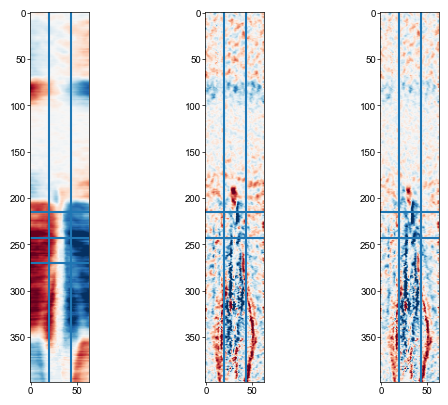

rep2


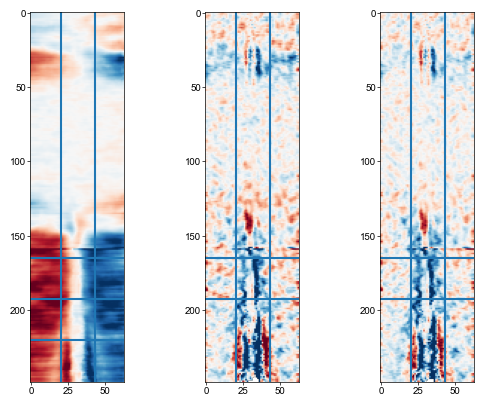

rep3


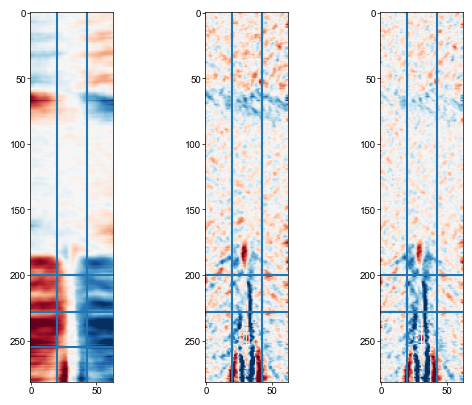

rep4


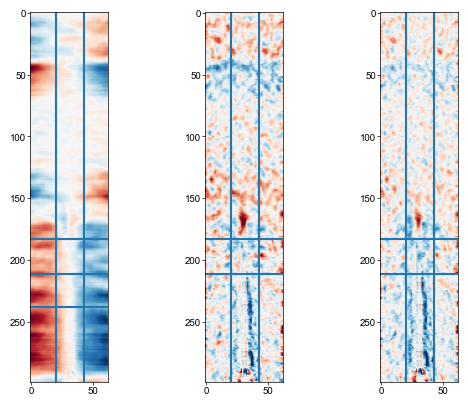

rep5


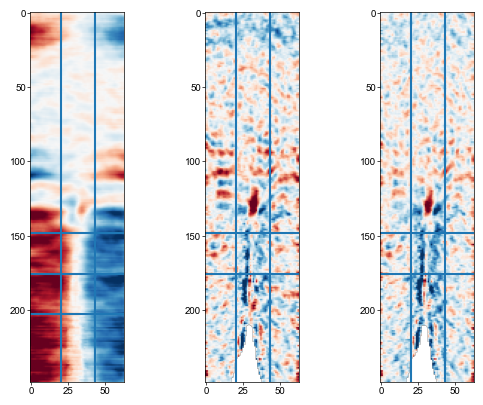

rep6


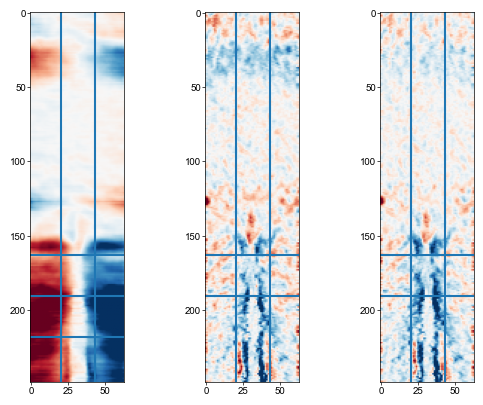

rep7


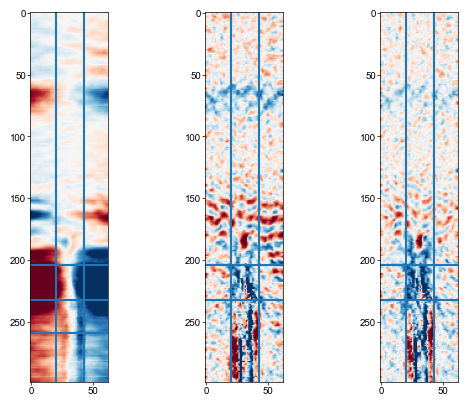

rep8


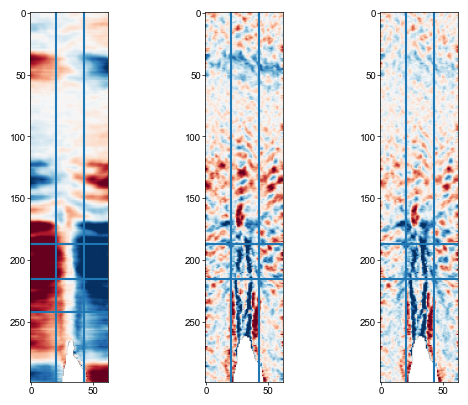

rep9


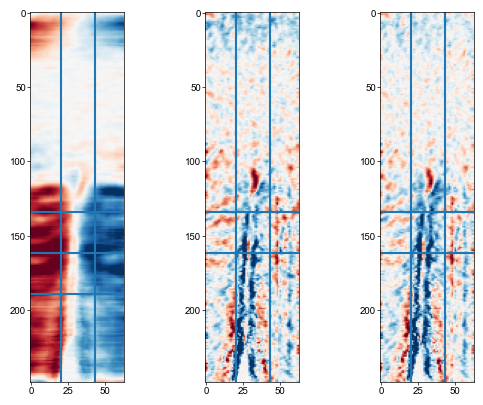

rep10


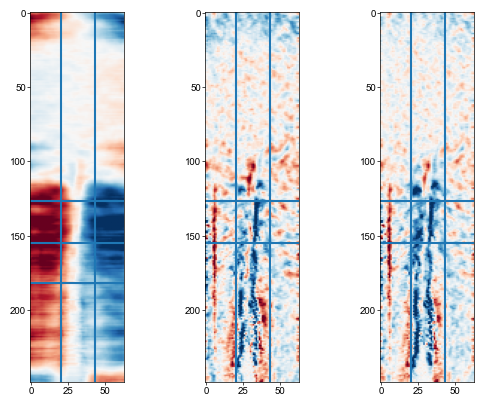

In [112]:
# piv
wt_piv_div_for_manual_measurement = []
wt_piv_div2_for_manual_measurement = []
for i in wt_data_info.index[:]:
    replicate = wt_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    frame_41p5mpf = round(replicate.ck1 + (-1 * 60 / time_interval))
    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    frame_45mpf = round(replicate.ck1 + (2.5 * 60 / time_interval))
    frame_50mpf = round(replicate.ck1 + (7.5 * 60 / time_interval))

    a = wt_images_for_adz_manual_measurement_data_2[wt_images_for_adz_manual_measurement_data_2['Slice'] == i+1].iloc[0]
    cabel_roi_x0, cable_roi_y0 = round(a['X'] - a['Width']/2), round(a['Y'] - a['Height']/2)
    cabel_roi_width, cabel_roi_height = a['Width'], a['Height']

    piv_xyuv= np.load(file_name[:-4] + '_flow1_xyuv.npz')
    piv_x, piv_y, piv_u, piv_v = piv_xyuv["x"], piv_xyuv["y"], piv_xyuv["u"], piv_xyuv["v"]

    piv_xs, piv_ys = piv_x.shape
    piv_v -= np.nanmean(piv_v, axis=(1,2), keepdims=True)

    piv_div = divergence(piv_x, piv_y, piv_u, piv_v, pixel_size=pixel_size)[0]
    piv_div_kymo = np.average(piv_div[:, 32-5:32+5], axis=1)

    piv_div2 = divergence(piv_x, piv_y, piv_u, piv_v, pixel_size=pixel_size)[1][1]
    piv_div2_kymo = np.average(piv_div2[:, 32-5:32+5], axis=1)

    piv_v_kymo = np.nanmean(piv_v[:, :], axis=1)

    plt.subplot(131)
    plt.imshow(piv_v_kymo, cmap='RdBu', vmin=-5, vmax=5)
    plt.gca().axhline(y = frame_45mpf)
    plt.gca().axhline(y = frame_47p5mpf)
    plt.gca().axhline(y = frame_50mpf)
    plt.gca().axvline(x = 20)
    plt.gca().axvline(x = piv_ys-20)
    plt.subplot(132)
    plt.imshow(piv_div_kymo, cmap='RdBu', vmin=-0.5, vmax=.5)
    plt.gca().axhline(y = frame_45mpf)
    plt.gca().axhline(y = frame_47p5mpf)
    plt.gca().axvline(x = 20)
    plt.gca().axvline(x = piv_ys-20)
    plt.subplot(133)
    plt.imshow(piv_div2_kymo, cmap='RdBu', vmin=-.5, vmax=.5)
    plt.gca().axhline(y = frame_45mpf)
    plt.gca().axhline(y = frame_47p5mpf)
    plt.gca().axvline(x = 20)
    plt.gca().axvline(x = piv_ys-20)
    plt.show()

    wt_piv_div_for_manual_measurement.append(piv_div_kymo[frame_41p5mpf:frame_47p5mpf])
    wt_piv_div2_for_manual_measurement.append(piv_div2_kymo[frame_41p5mpf:frame_47p5mpf])

    aaa = piv_v_kymo[frame_45mpf:frame_50mpf]
    aaa = np.nanmean([np.abs(aaa[:, :20]), np.abs(aaa[:, -20:])])

    surrounding_cortex_flow = aaa
    wt_data_info.loc[i, 'surrounding_cortex_flow'] = surrounding_cortex_flow

# Pad each array with NaN rows to match max_len
max_len = max(arr.shape[0] for arr in wt_piv_div_for_manual_measurement)
padded = []
for arr in wt_piv_div_for_manual_measurement:
    pad_len = max_len - arr.shape[0]
    if pad_len > 0:
        padding = np.full((pad_len, arr.shape[1]), np.nan)
        arr = np.vstack([arr, padding])
    padded.append(arr)

wt_piv_div_for_manual_measurement = np.array(wt_piv_div_for_manual_measurement)
skimage.io.imsave('wt//wt_piv_div_for_manual_measurement.tif', wt_piv_div_for_manual_measurement)
wt_piv_div2_for_manual_measurement = np.array(wt_piv_div2_for_manual_measurement)
skimage.io.imsave('wt//wt_piv_div2_for_manual_measurement.tif', wt_piv_div2_for_manual_measurement)

In [113]:
wt_piv_div_for_manual_measurement_data = pd.read_csv('wt//wt_piv_div_for_manual_measurement.csv')
wt_piv_div2_for_manual_measurement_data = pd.read_csv('wt//wt_piv_div2_for_manual_measurement.csv')

In [114]:
for i in wt_data_info.index[:]:
    replicate = wt_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = wt_piv_div_for_manual_measurement_data[wt_piv_div_for_manual_measurement_data['Slice'] == i+1]
    cable_compression_flow = - np.mean(a['Mean'])
    wt_data_info.loc[i, 'cable_compression_flow'] = cable_compression_flow

    a = wt_piv_div2_for_manual_measurement_data[wt_piv_div2_for_manual_measurement_data['Slice'] == i+1]
    cable_compression_flow = - np.mean(a['Mean'])
    wt_data_info.loc[i, 'cable_compression_flow_dvdy'] = cable_compression_flow

rep1
rep2
rep3
rep4
rep5
rep6
rep7
rep8
rep9
rep10


In [115]:
np.save('wt//wt_compression_rate_dvdy.npy', wt_data_info['cable_compression_flow_dvdy'])

### CARhoA

In [116]:
# carhoa_images_for_adz_manual_measurement = []
# for i in carhoa_data_info.index:
#     replicate = carhoa_data_info.loc[i]
#     print(replicate.rep_name)
#     file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
#     time_interval = replicate.time_interval
#     frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))

#     image_frame_47p5mpf = tifffile.TiffFile(file_name).series[0].asarray(key=frame_47p5mpf)
#     img_ck1_minus2_5m = skimage.transform.rescale(image_frame_47p5mpf, (0.5, 0.5), order=3, anti_aliasing=True)
#     p1, p99 = np.percentile(image_frame_47p5mpf, (1, 99))
#     img_ck1_minus2_5m = skimage.exposure.rescale_intensity(image_frame_47p5mpf, in_range=(p1, p99), out_range=(0, 255))

#     carhoa_images_for_adz_manual_measurement.append(image_frame_47p5mpf)
#     fig, ax = plt.subplots(figsize=[1.5, 1.5])
#     ax.imshow(image_frame_47p5mpf, cmap='inferno')
#     plt.show()

# skimage.io.imsave('carhoa//carhoa_images_for_adz_manual_measurement.tif', np.array(carhoa_images_for_adz_manual_measurement).astype(np.int16))

In [117]:
carhoa_images_for_adz_manual_measurement_data = pd.read_csv('carhoa//carhoa_images_for_adz_manual_measurement.csv')
carhoa_images_for_adz_manual_measurement_data_2 = pd.read_csv('carhoa//carhoa_images_for_furrow_position_manual_label.csv')

In [118]:
# adz width
for i in carhoa_data_info.index[:]:
    replicate = carhoa_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = carhoa_images_for_adz_manual_measurement_data[carhoa_images_for_adz_manual_measurement_data['Slice'] == i+1]
    a.loc[a['Height'] == 1, 'Height']=0
    adz_width = np.mean(a['Height']) * pixel_size
    carhoa_data_info.loc[i, 'adz_width'] = adz_width

rep56
rep67
rep68
rep72
rep76
rep77
rep80
rep81
rep82
rep83
rep84
rep87
rep88
rep96
rep97
rep103
rep105


In [119]:
# cable qxx
for i in carhoa_data_info.index:
    replicate = carhoa_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = carhoa_images_for_adz_manual_measurement_data_2[carhoa_images_for_adz_manual_measurement_data_2['Slice'] == i+1].iloc[0]
    cabel_roi_x0, cable_roi_y0 = round(a['X'] - a['Width']/2), round(a['Y'] - a['Height']/2)
    cabel_roi_width, cabel_roi_height = a['Width'], a['Height']

    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    image_frame_47p5mpf = tifffile.TiffFile(file_name).series[0].asarray(key=frame_47p5mpf)
    image_frame_47p5mpf_q = nematic_order_of_full_image(image_frame_47p5mpf, windowsize=int(30/30*40), qmin=1/30*40, qmax=15/30*40, print_minmax=False)
    image_frame_47p5mpf_qx, image_frame_47p5mpf_qy, image_frame_47p5mpf_qxx, image_frame_47p5mpf_qxy = image_frame_47p5mpf_q

    mask = (image_frame_47p5mpf_qx >= cabel_roi_x0) & (image_frame_47p5mpf_qx <= cabel_roi_x0 + cabel_roi_width) & (image_frame_47p5mpf_qy >= cable_roi_y0) & (image_frame_47p5mpf_qy <= cable_roi_y0 + cabel_roi_height)
    cabel_qxx = np.mean(image_frame_47p5mpf_qxx[mask])
    carhoa_data_info.loc[i, 'cable_qxx'] = cabel_qxx


rep56
rep67
rep68
rep72
rep76
rep77
rep80
rep81
rep82
rep83
rep84
rep87
rep88
rep96
rep97
rep103
rep105


rep56


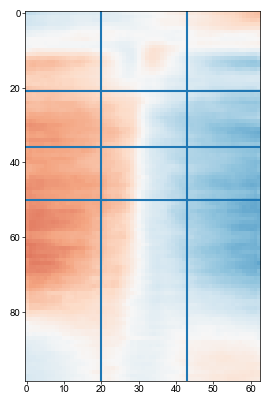

rep67


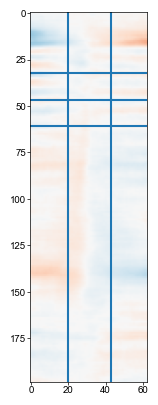

rep68


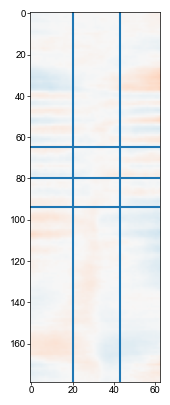

rep72


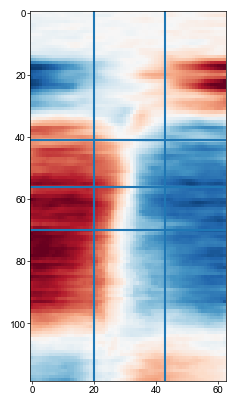

rep76


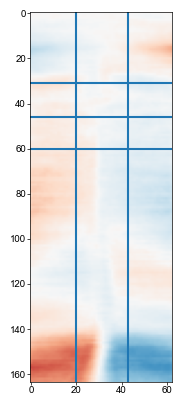

rep77


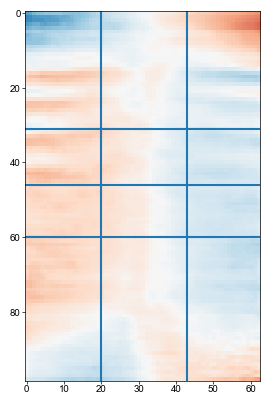

rep80


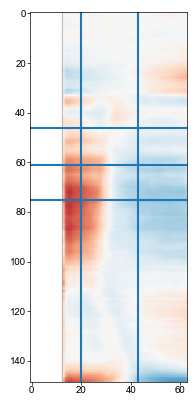

rep81


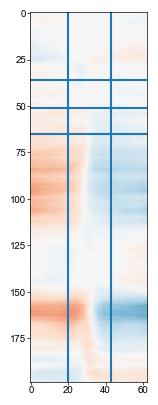

rep82


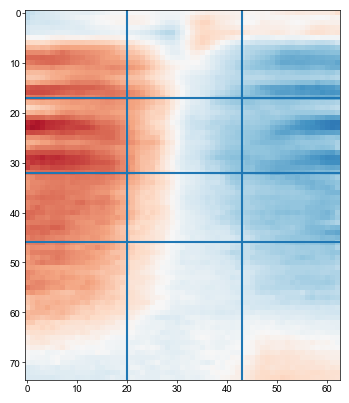

rep83


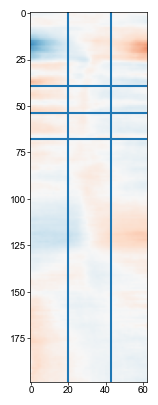

rep84


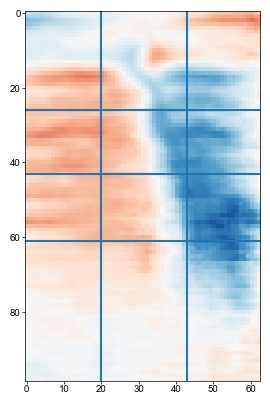

rep87


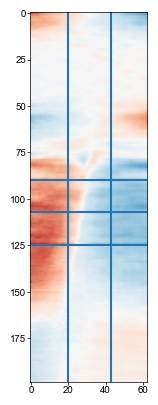

rep88


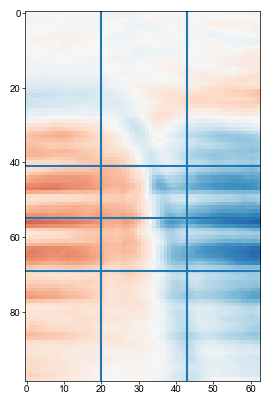

rep96


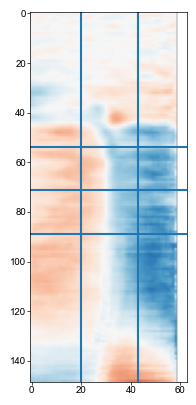

rep97


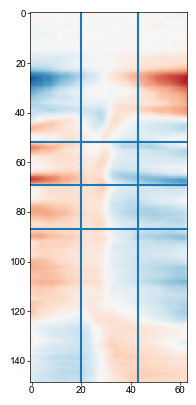

rep103


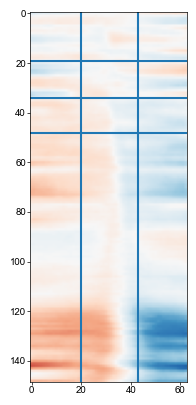

rep105


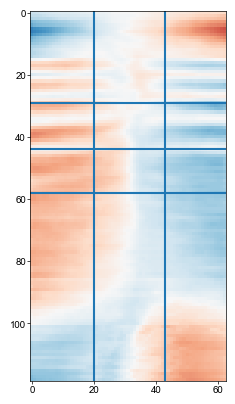

In [120]:
# piv
carhoa_piv_div_for_manual_measurement = []
for i in carhoa_data_info.index[:]:
    replicate = carhoa_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    frame_41p5mpf = round(replicate.ck1 + (-1 * 60 / time_interval))
    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    frame_45mpf = round(replicate.ck1 + (2.5 * 60 / time_interval))
    frame_50mpf = round(replicate.ck1 + (7.5 * 60 / time_interval))

    a = carhoa_images_for_adz_manual_measurement_data_2[carhoa_images_for_adz_manual_measurement_data_2['Slice'] == i+1].iloc[0]
    cabel_roi_x0, cable_roi_y0 = round(a['X'] - a['Width']/2), round(a['Y'] - a['Height']/2)
    cabel_roi_width, cabel_roi_height = a['Width'], a['Height']

    piv_xyuv= np.load(file_name[:-4] + '_flow1_xyuv.npz')
    piv_x, piv_y, piv_u, piv_v = piv_xyuv["x"], piv_xyuv["y"], piv_xyuv["u"], piv_xyuv["v"]

    piv_xs, piv_ys = piv_x.shape
    piv_v -= np.nanmean(piv_v, axis=(1,2), keepdims=True)
    piv_div = divergence(piv_x, piv_y, piv_u, piv_v, pixel_size=pixel_size)[0]
    piv_div_kymo = np.average(piv_div[:, 32-5:32+5], axis=1)
    piv_v_kymo = np.nanmean(piv_v[:, :], axis=1)

    plt.imshow(piv_v_kymo, cmap='RdBu', vmin=-5, vmax=5)
    plt.gca().axhline(y = frame_45mpf)
    plt.gca().axhline(y = frame_47p5mpf)
    plt.gca().axhline(y = frame_50mpf)
    plt.gca().axvline(x = 20)
    plt.gca().axvline(x = piv_ys-20)
    plt.show()

    carhoa_piv_div_for_manual_measurement.append(piv_div_kymo[:frame_47p5mpf])

    aaa = piv_v_kymo[frame_45mpf:frame_50mpf]
    aaa = np.nanmean([np.abs(aaa[:, :20]), np.abs(aaa[:, -20:])])

    surrounding_cortex_flow = aaa
    carhoa_data_info.loc[i, 'surrounding_cortex_flow'] = surrounding_cortex_flow

# Pad each array with NaN rows to match max_len
max_len = max(arr.shape[0] for arr in carhoa_piv_div_for_manual_measurement)
padded = []
for arr in carhoa_piv_div_for_manual_measurement:
    pad_len = max_len - arr.shape[0]
    if pad_len > 0:
        padding = np.full((pad_len, arr.shape[1]), np.nan)
        arr = np.vstack([arr, padding])
    padded.append(arr)

carhoa_piv_div_for_manual_measurement = np.array(padded)
skimage.io.imsave('carhoa//carhoa_piv_div_for_manual_measurement.tif', np.array(carhoa_piv_div_for_manual_measurement))

In [121]:
carhoa_piv_div_for_manual_measurement_data = pd.read_csv('carhoa//carhoa_piv_div_for_manual_measurement.csv')

In [122]:
for i in carhoa_data_info.index[:]:
    replicate = carhoa_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    a = carhoa_piv_div_for_manual_measurement_data[carhoa_piv_div_for_manual_measurement_data['Slice'] == i+1]
    cable_compression_flow = - np.mean(a['Mean'])
    carhoa_data_info.loc[i, 'cable_compression_flow'] = cable_compression_flow

rep56
rep67
rep68
rep72
rep76
rep77
rep80
rep81
rep82
rep83
rep84
rep87
rep88
rep96
rep97
rep103
rep105


## Plot them

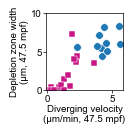

In [123]:
fig,ax=plt.subplots(figsize=[1, 1])

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow', y='adz_width', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow', y='adz_width', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

# ax.set_xlim(0, 7.5)
# ax.set_xticks(np.arange(0,8,2.5)) 
ax.set_ylim(0, 10)
# ax.set_yticks(np.arange(0,11,2.5)) 


ax.set_xlabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(\u03BCm, 47.5 mpf)', fontsize=7)

# ax.set_xlabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)', fontsize=7)
# ax.set_ylabel('Depletion zone width\n(\u03BCm, 47.5 mpf)', fontsize=7)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
# plt.savefig('diverging-no_insilico.svg')
plt.show()

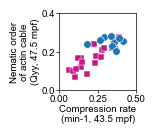

In [124]:
fig,ax=plt.subplots(figsize=[1, 1])

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='cable_compression_flow', y='cable_qxx', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='cable_compression_flow', y='cable_qxx', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 0.5)
# ax.set_xticks(np.arange(0,7,2)) 
ax.set_ylim(0, 0.4)
# ax.set_yticks(np.arange(0,11,2.5)) 
ax.set_xlabel('Compression rate\n(min-1, 43.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order\nof actin cable\n(Qyy, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
# plt.savefig('diverging-no_insilico.svg')
plt.show()

### individual quantities

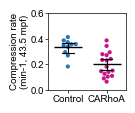

Shapiro p-values: 0.484, 0.220 → normal
Levene p-value: 0.105 → equal variance

Student's t-test: stat=-3.880, p=0.0007


In [125]:
df = pd.concat([wt_data_info, carhoa_data_info], ignore_index=True)

fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='cable_compression_flow', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='cable_compression_flow',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 0.6)
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Compression rate\n(min-1, 43.5 mpf)')
plt.savefig('ctrl-carhoa_compression_rate.svg')
plt.show()

groups = [grp['cable_compression_flow'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

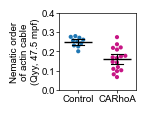

Shapiro p-values: 0.839, 0.632 → normal
Levene p-value: 0.016 → unequal variance

Welch's t-test: stat=-5.505, p=0.0000128346


In [126]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='cable_qxx', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='cable_qxx',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 0.4)
ax.set_yticks(np.arange(0, 0.5, 0.1))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Nematic order\nof actin cable\n(Qyy, 47.5 mpf)')
plt.savefig('ctrl-carhoa_nematic_order.svg')
plt.show()

groups = [grp['cable_qxx'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

In [127]:
potential_qxx_values = df.groupby('cortex_flow_analysis')['cable_qxx'].mean()
display(potential_qxx_values)

potential_qxx_ratio = potential_qxx_values[0] / potential_qxx_values[1]
print(potential_qxx_ratio)

cortex_flow_analysis
carhoa    0.159038
wt        0.249228
Name: cable_qxx, dtype: float64

0.6381213887599999


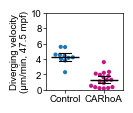

Shapiro p-values: 0.148, 0.203 → normal
Levene p-value: 0.515 → equal variance

Student's t-test: stat=-7.963, p=0.0000000255


In [128]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='surrounding_cortex_flow', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='surrounding_cortex_flow',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0, 11, 2))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)')
plt.savefig('ctrl-carhoa_diverging velocity.svg')

plt.show()

groups = [grp['surrounding_cortex_flow'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

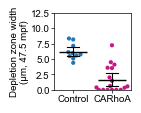

Shapiro p-values: 0.001, 0.320 → not normal
Levene p-value: 0.349 → equal variance

Mann-Whitney U: stat=9.000, p=0.0001382703


In [129]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='adz_width', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='adz_width',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 12.5)
ax.set_yticks(np.arange(0, 15, 2.5))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Depletion zone width\n(\u03BCm, 47.5 mpf)')
plt.savefig('ctrl-carhoa_adz_width.svg')

plt.show()


groups = [grp['adz_width'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

### plot for the paper (fig. 5E, 5E')

In [130]:
wt_data_info['surrounding_cortex_flow_norm'] = wt_data_info['surrounding_cortex_flow']/(wt_data_info['surrounding_cortex_flow'].mean())
wt_data_info['cable_qxx_norm'] = wt_data_info['cable_qxx']/(wt_data_info['cable_qxx'].mean())
wt_data_info['adz_width_norm'] = wt_data_info['adz_width']/(wt_data_info['adz_width'].mean())

carhoa_data_info['surrounding_cortex_flow_norm'] = carhoa_data_info['surrounding_cortex_flow']/(wt_data_info['surrounding_cortex_flow'].mean())
carhoa_data_info['cable_qxx_norm'] = carhoa_data_info['cable_qxx']/(wt_data_info['cable_qxx'].mean())
carhoa_data_info['adz_width_norm'] = carhoa_data_info['adz_width']/(wt_data_info['adz_width'].mean())

In [131]:
np.savez("cable_nematic_order_wt_vs_carhoa.npz",
         wt = wt_data_info['cable_qxx_norm'],
         carhoa = carhoa_data_info['cable_qxx_norm'])

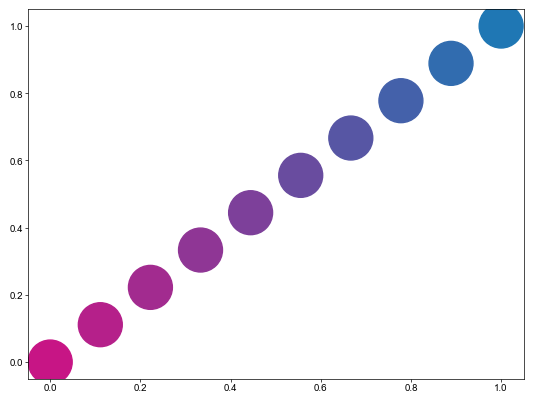

In [132]:
# create a new colormap

from matplotlib.colors import LinearSegmentedColormap
from xint_toolbox import colored_line

def two_color_colormap(color1, color2, name="custom_cmap"):
    """
    Create a linear colormap between two colors.

    Parameters:
        color1 (str or tuple): First color (e.g., "blue" or (0.1, 0.2, 0.5)).
        color2 (str or tuple): Second color (e.g., "red" or (0.8, 0.2, 0.3)).
        name (str): Name of the colormap.

    Returns:
        LinearSegmentedColormap: A matplotlib colormap object.
    """
    return LinearSegmentedColormap.from_list(name, [color1, color2])

# Example usage
tabblue_mediumvioletred_cmap = two_color_colormap("tab:blue", "mediumvioletred")
mediumvioletred_tabblue_cmap = two_color_colormap("mediumvioletred", "tab:blue")

# Plot an example gradient
import numpy as np
gradient = np.linspace(0, 1, 10)
plt.scatter(gradient, gradient, c=mediumvioletred_tabblue_cmap(gradient), s=1000)
plt.show()


In [133]:
simulations = np.load('simulations_yil//caRhoA_20260610.npz')
simulations

NpzFile 'simulations_yil//caRhoA_20260610.npz' with keys: velocities, widths, param_sets, nematic

In [134]:
simulations['param_sets']

array([1.1 , 1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55])

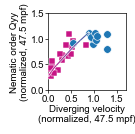

In [135]:
sim_surrounding_cortex_flow = simulations['velocities'][1]
sim_cable_qxx = simulations['nematic'][1]
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

ax.plot(sim_surrounding_cortex_flow, sim_cable_qxx, color='white', zorder=9, lw=1.6)
colored_line(x=sim_surrounding_cortex_flow, y=sim_cable_qxx, c=sim_param, ax=ax, cmap=mediumvioletred_tabblue_cmap, ls='-', lw=0.8, zorder=10, vmin=0.5, vmax=1.2)
# ax.scatter(x=sim_surrounding_cortex_flow, y=sim_cable_qxx, marker='x', c='white', cmap=mediumvioletred_tabblue_cmap, s=15, linewidth=2, zorder=9)
# ax.scatter(x=sim_surrounding_cortex_flow, y=sim_cable_qxx, marker='x', c=sim_param, cmap=mediumvioletred_tabblue_cmap, s=10, linewidth=1, zorder=10)

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.7)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico.svg')
plt.show()

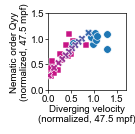

In [136]:
sim_surrounding_cortex_flow = simulations['velocities'][1]
sim_cable_qxx = simulations['nematic'][1]
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

# ax.plot(sim_surrounding_cortex_flow, sim_cable_qxx, color='white', zorder=9, lw=1.2)
# colored_line(x=sim_surrounding_cortex_flow, y=sim_cable_qxx, marker='x', c=sim_param, ax=ax, cmap=mediumvioletred_tabblue_cmap, ls='-', lw=0.8, zorder=10)
sns.scatterplot(x=sim_surrounding_cortex_flow, y=sim_cable_qxx, marker='X', hue=sim_param, hue_norm=(0.5, 1.2), palette = mediumvioletred_tabblue_cmap, s= 30, zorder=7, legend=False)

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.7)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico_2.svg')
plt.show()

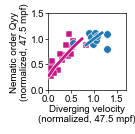

In [137]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_cable_qxx_wt, sim_cable_qxx_lowerchi = simulations['nematic']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1,1 ])

sim_param_threshs = 0.9, 1
ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'tab:blue', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param<=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param<=sim_param_threshs[0]], 'tab:blue', ls=':', lw=2, zorder=10)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'mediumvioletred', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param>=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param>=sim_param_threshs[1]], 'mediumvioletred', ls=':', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.7)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico3.svg')
plt.show()

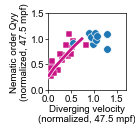

In [138]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_cable_qxx_wt, sim_cable_qxx_lowerchi = simulations['nematic']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1,1 ])

sim_param_threshs = 0.9, 1
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'tab:blue', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param<=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param<=sim_param_threshs[0]], 'tab:blue', ls=':', lw=2, zorder=10)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'mediumvioletred', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param>=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param>=sim_param_threshs[1]], 'mediumvioletred', ls=':', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.7)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico4.svg')
plt.show()

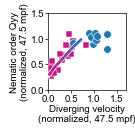

In [139]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_cable_qxx_wt, sim_cable_qxx_lowerchi = simulations['nematic']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1,1 ])

sim_param_threshs = 0.9, 1
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'tab:blue', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param<=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param<=sim_param_threshs[0]], 'tab:blue', ls=':', lw=2, zorder=10)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'mediumvioletred', ls='-', lw=2, zorder=10)
colored_line(x=sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]],
             y=sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]],
             c=sim_param[sim_param<=sim_param_threshs[1]], cmap=mediumvioletred_tabblue_cmap, ax=ax, vmin=sim_param[sim_param<=sim_param_threshs[1]].min(), vmax=sim_param[sim_param<=sim_param_threshs[1]].max(),
             ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param>=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param>=sim_param_threshs[1]], 'mediumvioletred', ls=':', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.7)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico5.svg')
plt.show()

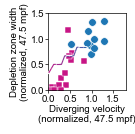

In [140]:
sim_surrounding_cortex_flow = simulations['velocities'][1]
sim_adz_width_norm = simulations['widths'][1]
# sim_adz_width_norm = (sim_adz_width_norm-0.5)/0.5
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

ax.plot(sim_surrounding_cortex_flow, sim_adz_width_norm, color='white', zorder=9, lw=1.6)
colored_line(x=sim_surrounding_cortex_flow, y=sim_adz_width_norm, c=sim_param, ax=ax, cmap=mediumvioletred_tabblue_cmap, ls='-', lw=0.8, zorder=10, vmin=0.5, vmax=1.2)
# ax.scatter(x=sim_surrounding_cortex_flow, y=sim_adz_width_norm, marker='x', c='white', cmap=mediumvioletred_tabblue_cmap, s=15, linewidth=2.5, zorder=9)
# ax.scatter(x=sim_surrounding_cortex_flow, y=sim_adz_width_norm, marker='x', c=sim_param, cmap=mediumvioletred_tabblue_cmap, s=10, linewidth=1.5, zorder=10)

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 1.8)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
ax.set_yticks(np.arange(0, 2, 0.5)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-adz-width_insilico.svg')
plt.show()

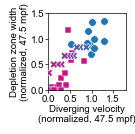

In [141]:
sim_surrounding_cortex_flow = simulations['velocities'][1]
sim_adz_width_norm = simulations['widths'][1]
# sim_adz_width_norm = (sim_adz_width_norm-0.5)/0.5
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

# ax.plot(sim_surrounding_cortex_flow, sim_adz_width_norm, 'x', color='black', zorder=9, lw=2.4)
# colored_line(x=sim_surrounding_cortex_flow, y=sim_adz_width_norm, c=sim_param, ax=ax, cmap=mediumvioletred_tabblue_cmap, ls='-', lw=1.2, zorder=10)
sns.scatterplot(x=sim_surrounding_cortex_flow, y=sim_adz_width_norm, marker='X', hue=sim_param, hue_norm=(0.5, 1.2), palette = mediumvioletred_tabblue_cmap, s= 30, zorder=7, legend=False)



sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 1.8)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
ax.set_yticks(np.arange(0, 2, 0.5)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-adz-width_insilico_2.svg')
plt.show()

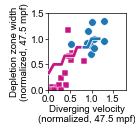

In [142]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_adz_width_wt, sim_adz_width_lowerchi = simulations['widths']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

sim_param_threshs = 0.9, 1
ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='tab:blue', ls='-', lw=2, zorder=10)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='mediumvioletred', ls='-', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 1.8)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
ax.set_yticks(np.arange(0, 2, 0.5)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-adz-width_insilico3.svg')
plt.show()


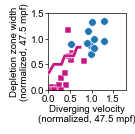

In [143]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_adz_width_wt, sim_adz_width_lowerchi = simulations['widths']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

sim_param_threshs = 0.9, 1
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='tab:blue', ls='-', lw=2, zorder=10)
ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='mediumvioletred', ls='-', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 1.8)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
ax.set_yticks(np.arange(0, 2, 0.5)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-adz-width_insilico4.svg')
plt.show()

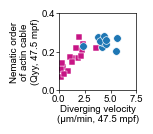

In [144]:
fig,ax=plt.subplots(figsize=[1, 1])

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow', y='cable_qxx', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow', y='cable_qxx', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 7.5)
ax.set_xticks(np.arange(0,8,2.5)) 
ax.set_ylim(0, 0.4)
# ax.set_yticks(np.arange(0,11,2.5)) 
ax.set_xlabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order\nof actin cable\n(Qyy, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
# plt.savefig('diverging-no_insilico.svg')
plt.show()

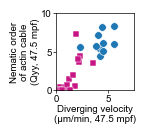

In [145]:
fig,ax=plt.subplots(figsize=[1, 1])

sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow', y='adz_width', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow', y='adz_width', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 7.5)
# ax.set_xticks(np.arange(0,7,2)) 
ax.set_ylim(0, 10)
# ax.set_yticks(np.arange(0,11,2.5)) 
ax.set_xlabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order\nof actin cable\n(Qyy, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
# plt.savefig('diverging-no_insilico.svg')
plt.show()

## Actin-depletion zone -- other strategy

### WT

rep1


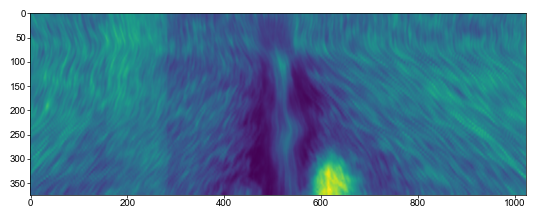

rep2


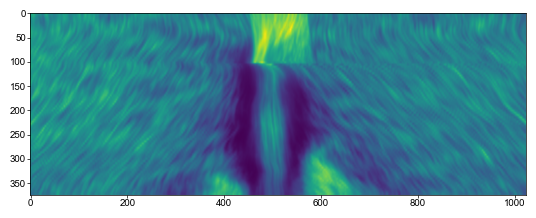

rep3


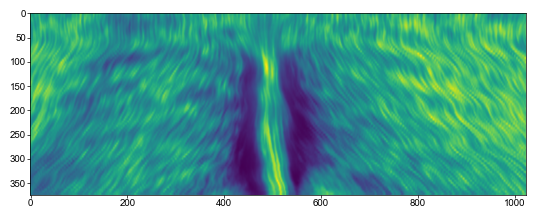

rep4


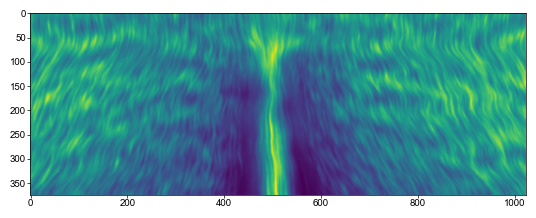

rep5


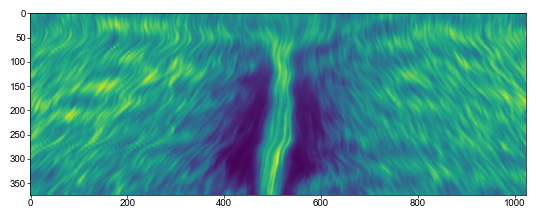

rep6


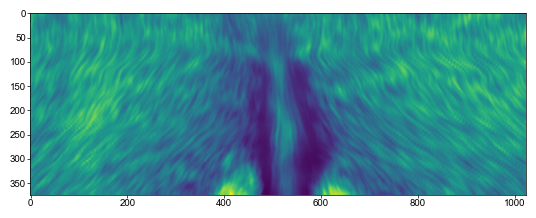

rep7


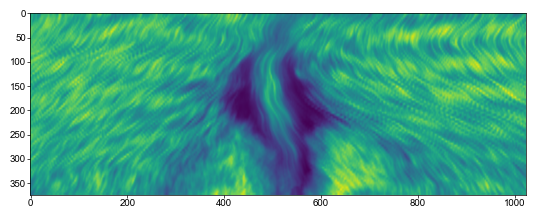

rep8


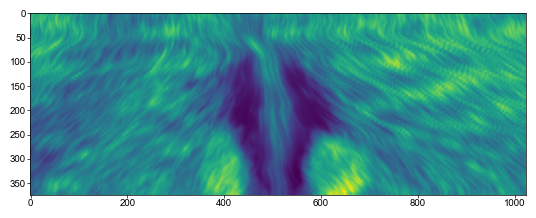

rep9


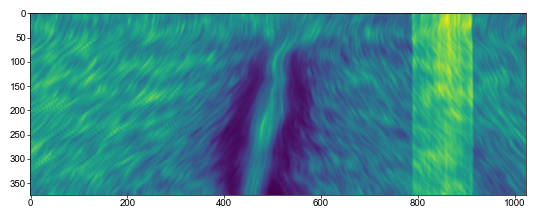

rep10


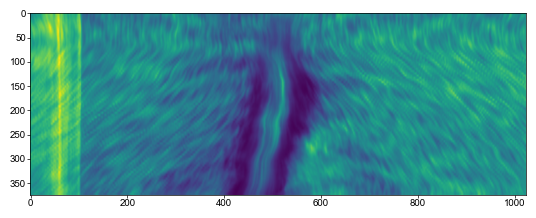

In [146]:
kymos = []

for i in wt_data_info.index[:]:
    replicate = wt_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    time_interval = replicate.time_interval
    frame_40mpf = round(replicate.ck1 + (-2.5 * 60 / time_interval))
    frame_42p5mpf = round(replicate.ck1 + (0 * 60 / time_interval))
    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    frame_50mpf = round(replicate.ck1 + (7.5 * 60 / time_interval))

    image = skimage.io.imread(file_name)

    kymo = np.nanmean(image[:, :, 512-100:512+100], axis=2)
    kymo = kymo[frame_42p5mpf:frame_50mpf]

    kymo = skimage.transform.resize(kymo, [750/2, 1024])

    fig,ax=plt.subplots()
    ax.imshow(kymo, aspect=1)
    plt.show()

    kymos.append(kymo)
    
kymos = np.array(kymos).astype(np.int16)
skimage.io.imsave('wt//wt_kymos_for_adz.tif', kymos)

In [147]:
images = skimage.io.imread('wt//wt_kymos_for_adz.tif')
rep_num = images.shape[0]

0 | rep1


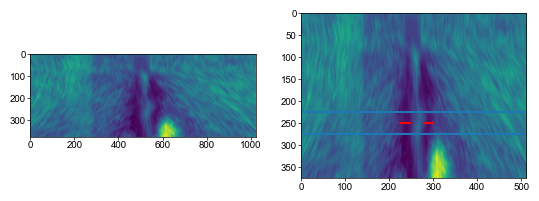

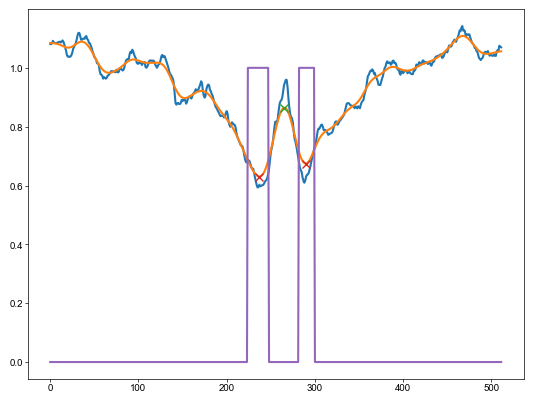

1 | rep2


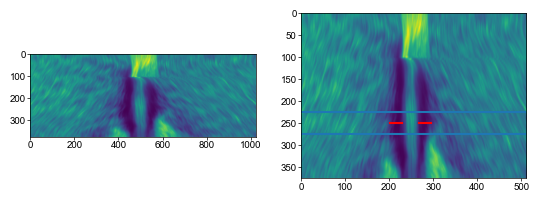

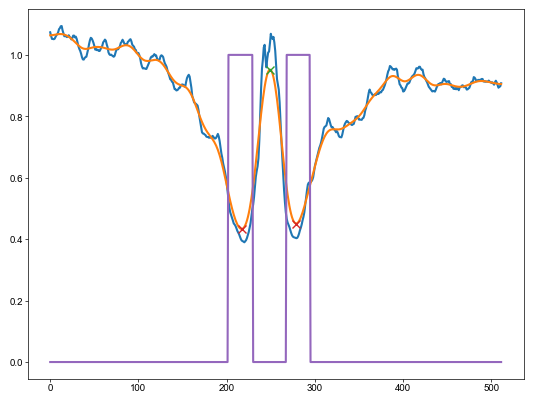

2 | rep3


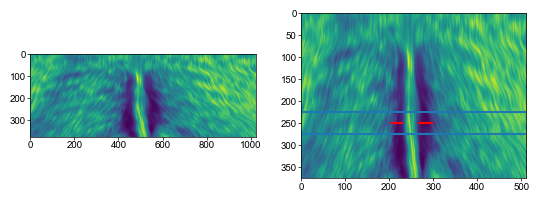

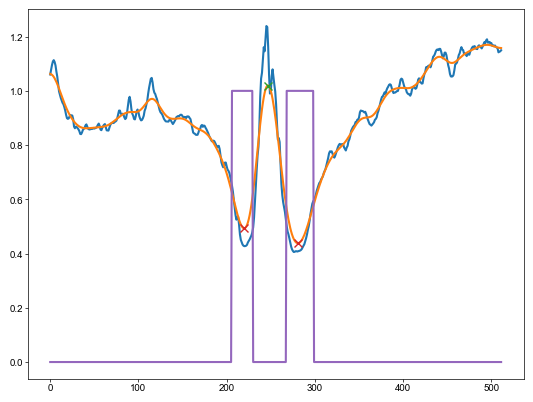

3 | rep4


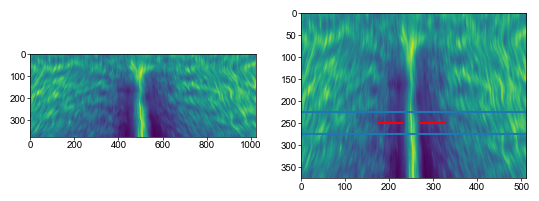

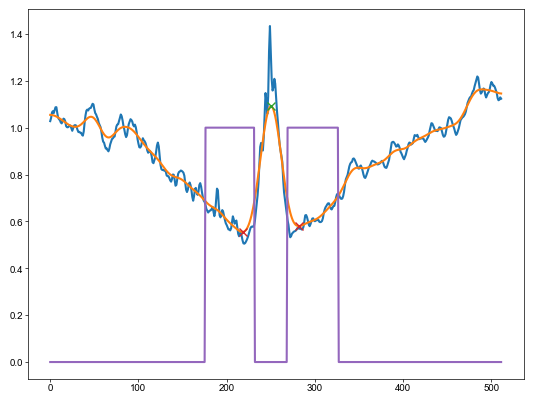

4 | rep5


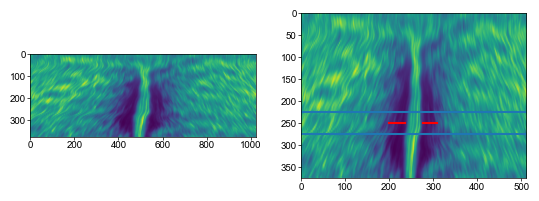

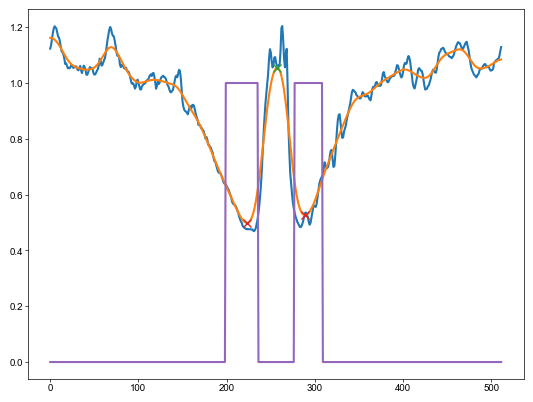

5 | rep6


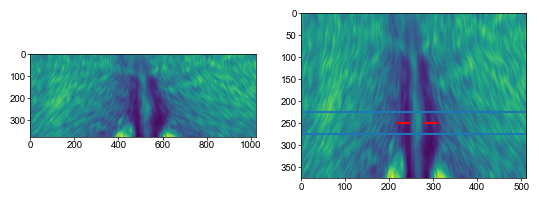

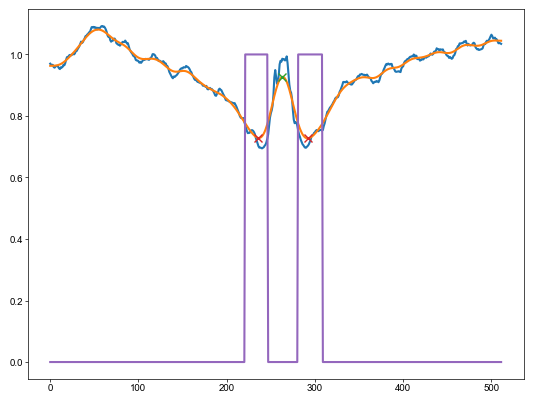

6 | rep7


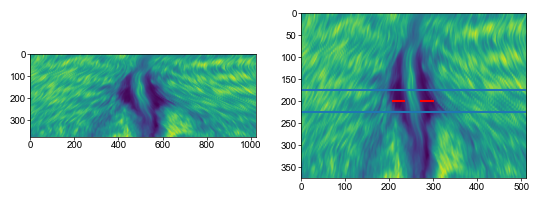

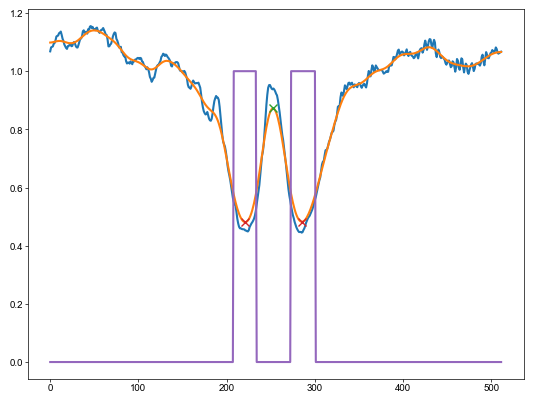

7 | rep8


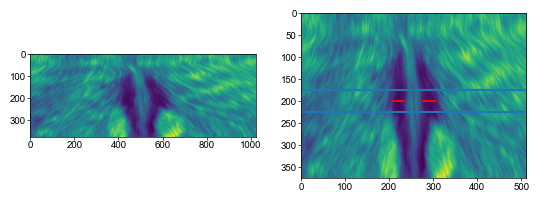

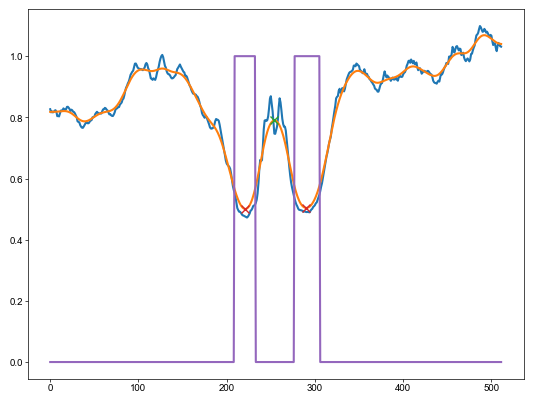

8 | rep9


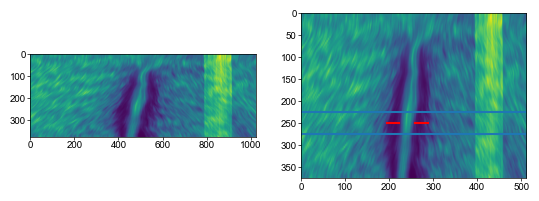

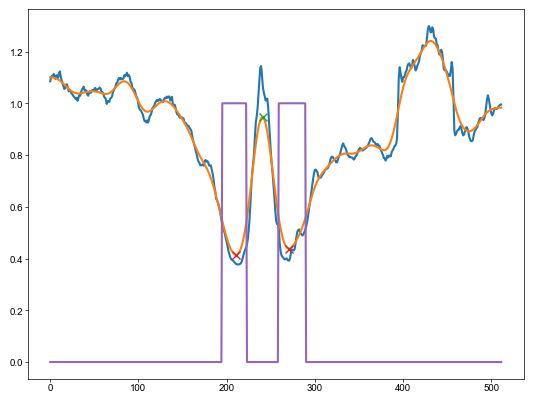

9 | rep10


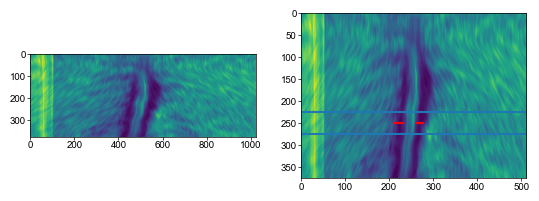

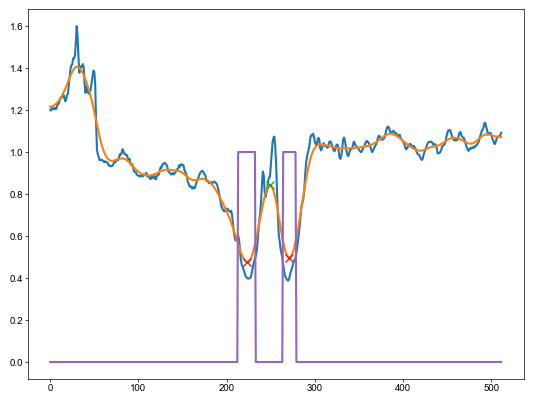

In [148]:
for i in range(rep_num):
# for i in range(2):
    print(i, '|', wt_data_info.loc[i, 'rep_name'])
    image = images[i]
    fs, xs = image.shape
    # correction = images_correction[i]
    correction = np.zeros_like(image)
    if np.any(correction==255):
        new_image = np.zeros_like(image)
        for f in range(fs):
            center = np.where(correction[f]==255)[0][0]
            # print(center)
            if center>512:
                new_image[f, 0:1024-(center-512)] = image[f, center-512:1024]
            else:
                new_image[f, 512-center:1024] = image[f, 0:1024-(512-center)]
    else:
        new_image=image

    new_image = new_image.astype(float)
    new_image = skimage.transform.rescale(new_image, (1,0.5))
    new_image /= np.nanmean(new_image[0])

    if i in [6,7]:
        range_to_average = np.array([350/2,450/2]).astype(int)
    else:
        range_to_average = np.array([450/2,550/2]).astype(int)

    intensity_profile = np.nanmean(new_image[range_to_average[0]:range_to_average[1]], axis=0)
    intensity_profile_1 = scipy.ndimage.gaussian_filter(intensity_profile, sigma=7.5)
    peaks, _ = scipy.signal.find_peaks(intensity_profile_1)
    peak = peaks[find_closest(peaks, 1024*0.5/2)[1]]
    troughs, _ = scipy.signal.find_peaks(-intensity_profile_1)
    troughs = find_closest_two(troughs, peak)[0]
    troughs = np.sort(troughs)

    # thresh1, thresh2 = (intensity_profile_1[peak] + )/2
    frac= .25
    thresh1, thresh2 = (intensity_profile_1[peak] - intensity_profile_1[troughs]) *frac + intensity_profile_1[troughs]

    mask1 =     intensity_profile_1 < thresh1
    mask1 = skimage.morphology.label(mask1)
    a = mask1[troughs[0]]
    mask1 = mask1==a
    adzwidth1 = np.sum(mask1)

    mask2 =     intensity_profile_1 < thresh2
    mask2 = skimage.morphology.label(mask2)
    a = mask2[troughs[1]]
    mask2 = mask2==a
    adzwidth2 = np.sum(mask2)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(image)

    axs[1].imshow(new_image)
    axs[1].axhline(y = range_to_average[0])
    axs[1].axhline(y = range_to_average[1])
    axs[1].plot(np.where(mask1)[0][[0, -1]], [np.mean(range_to_average)]*2, color='red')
    axs[1].plot(np.where(mask2)[0][[0, -1]], [np.mean(range_to_average)]*2, color='red')
    plt.show()

    fig,ax = plt.subplots()
    ax.plot(intensity_profile)
    ax.plot(intensity_profile_1)
    ax.plot(peak, intensity_profile_1[peak], 'x')
    ax.plot(troughs, intensity_profile_1[troughs], 'x')
    ax.plot(mask1 + mask2)
    plt.show()

    pixel_size = wt_data_info.loc[i, 'pixel_size']
    wt_data_info.loc[i, 'adz_width_2'] = (adzwidth1 + adzwidth2)/2 * (pixel_size*2)

### carhoa

rep56


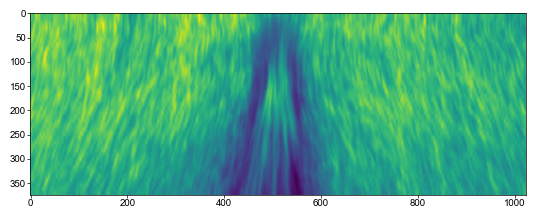

rep67


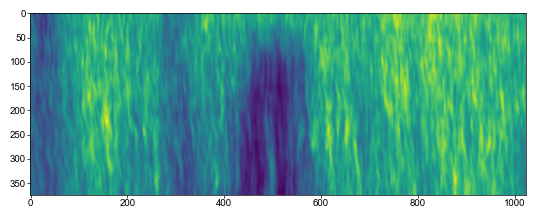

rep68


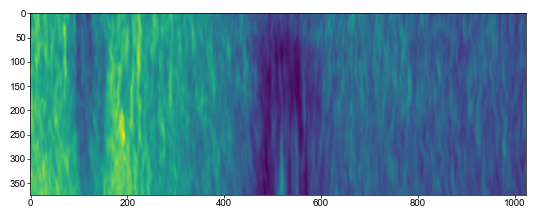

rep72


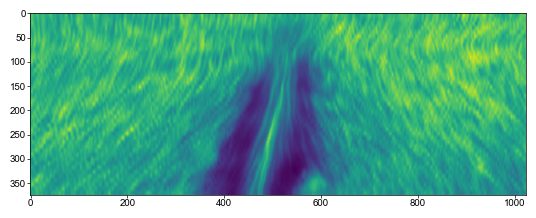

rep76


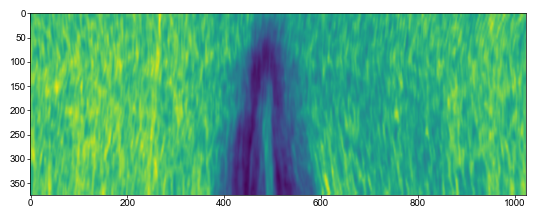

rep77


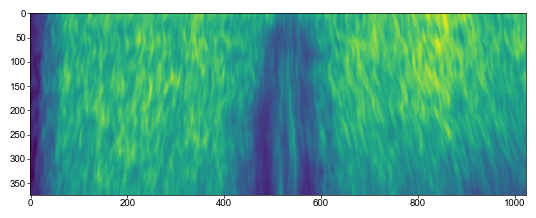

rep80


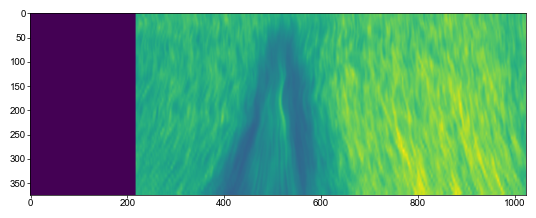

rep81


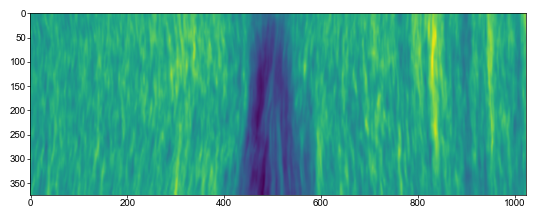

rep82


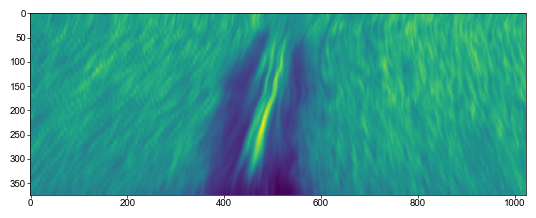

rep83


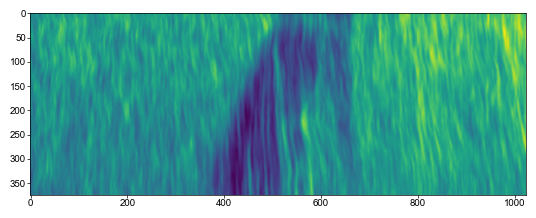

rep84


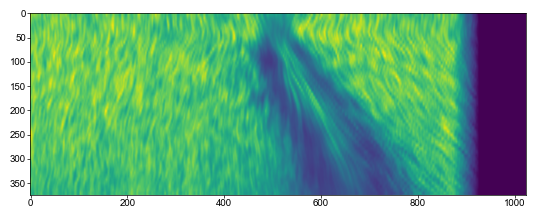

rep87


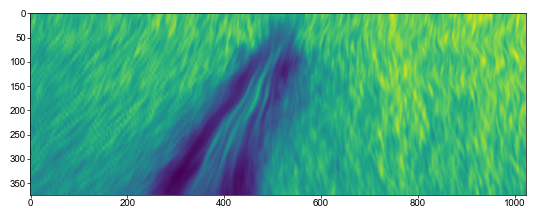

rep88


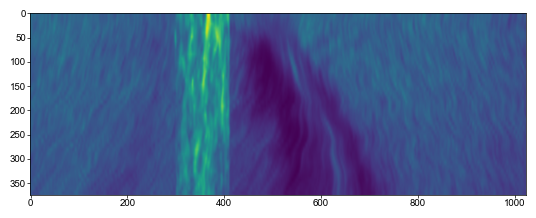

rep96


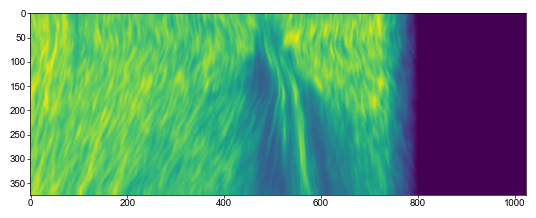

rep97


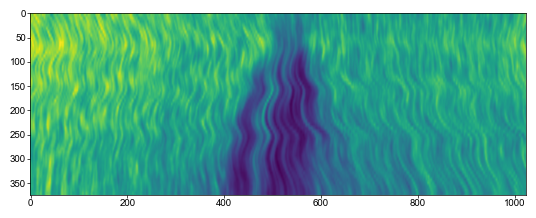

rep103


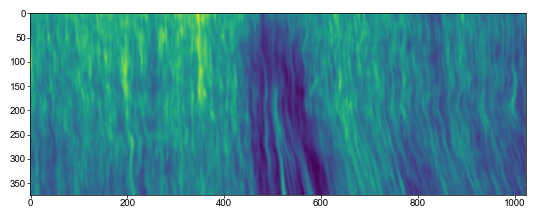

rep105


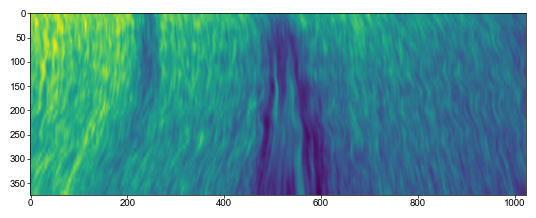

In [149]:
kymos = []

for i in carhoa_data_info.index[:]:
    replicate = carhoa_data_info.loc[i]
    print(replicate.rep_name)
    file_name = replicate.folder +'//' + replicate.rep_name + '_roi4.tif'
    time_interval = replicate.time_interval
    frame_40mpf = round(replicate.ck1 + (-2.5 * 60 / time_interval))
    frame_42p5mpf = round(replicate.ck1 + (0 * 60 / time_interval))
    frame_47p5mpf = round(replicate.ck1 + (5 * 60 / time_interval))
    frame_50mpf = round(replicate.ck1 + (7.5 * 60 / time_interval))

    image = skimage.io.imread(file_name)

    kymo = np.nanmean(image[:, :, 512-100:512+100], axis=2)
    kymo = kymo[frame_42p5mpf:frame_50mpf]

    kymo = skimage.transform.resize(kymo, [750/2, 1024])

    fig,ax=plt.subplots()
    ax.imshow(kymo, aspect=1)
    plt.show()

    kymos.append(kymo)
kymos = np.array(kymos).astype(np.int16)
skimage.io.imsave('carhoa//carhoa_kymos_for_adz.tif', kymos)

In [150]:
images = skimage.io.imread('carhoa//carhoa_kymos_for_adz.tif')
images_correction = skimage.io.imread('carhoa//carhoa_kymos_for_adz_correction.tif')
rep_num = images.shape[0]

[227 282]


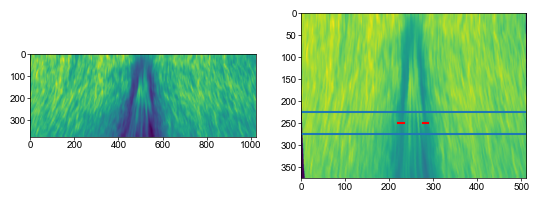

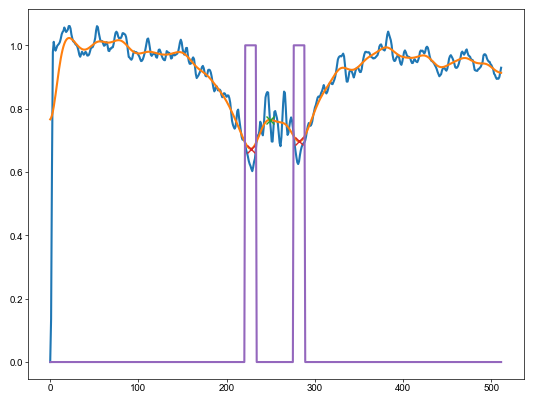

[232 257]


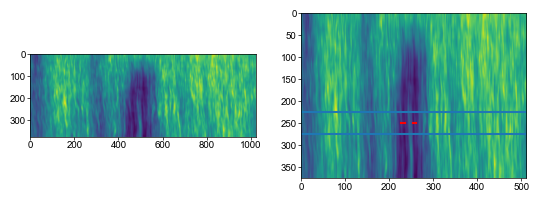

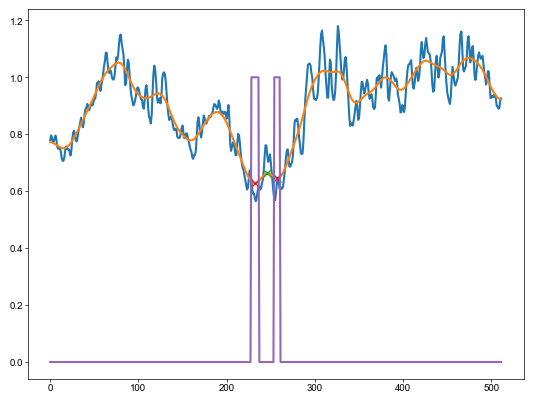

[245 280]


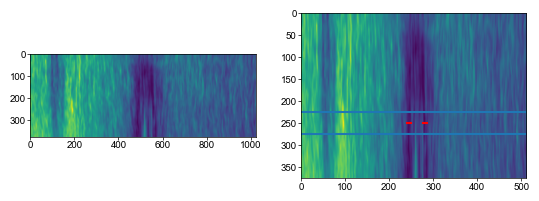

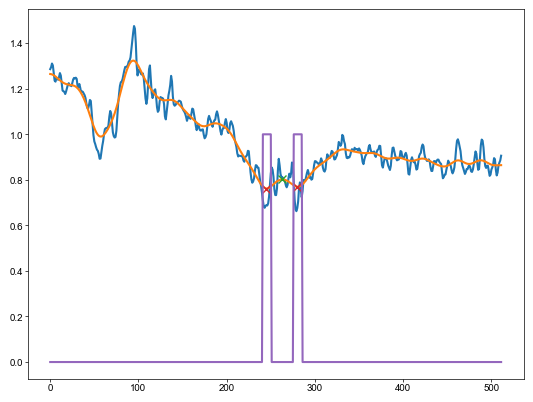

[226 285]


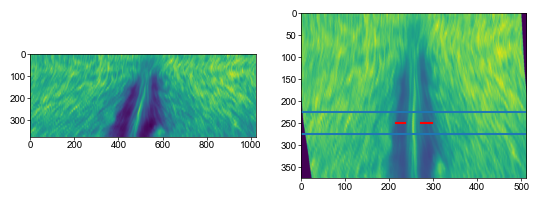

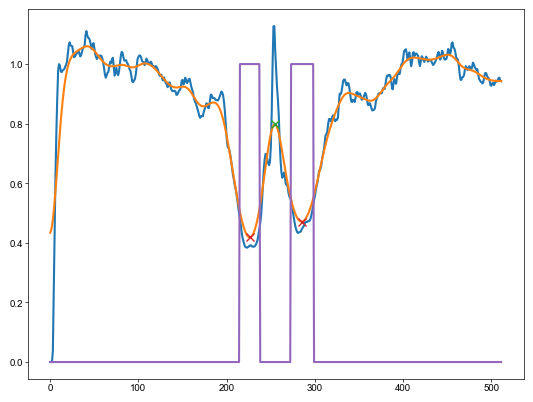

[224 260]


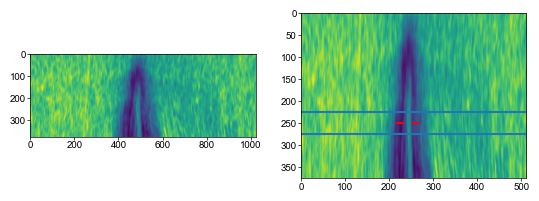

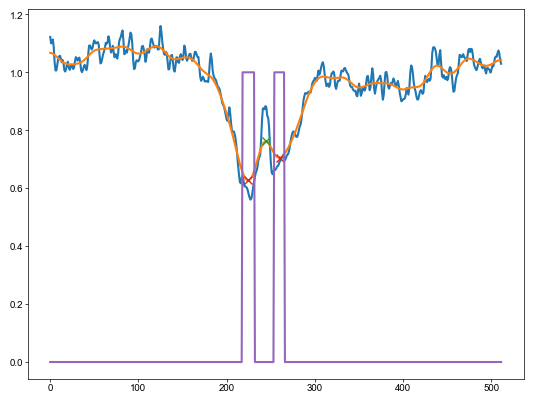

[241 284]


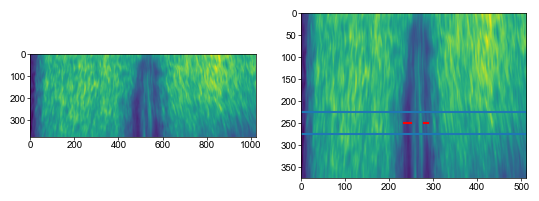

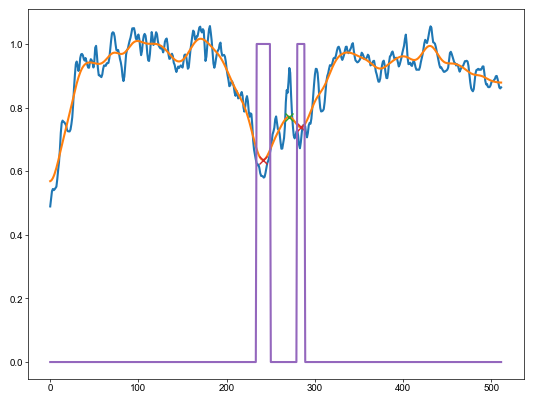

[228 279]


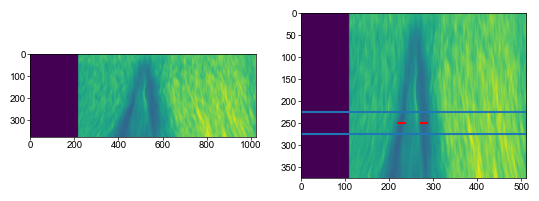

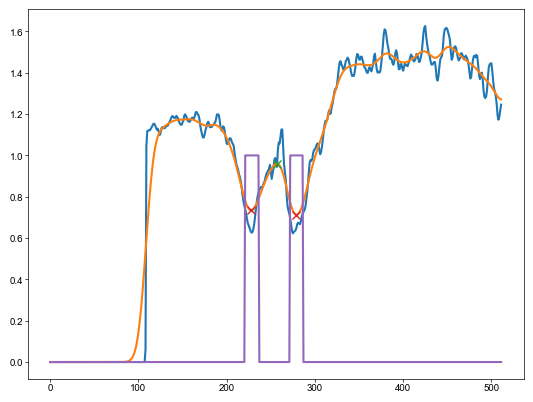

[236 260]


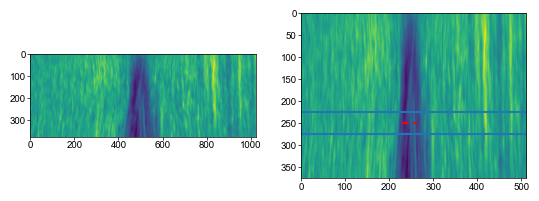

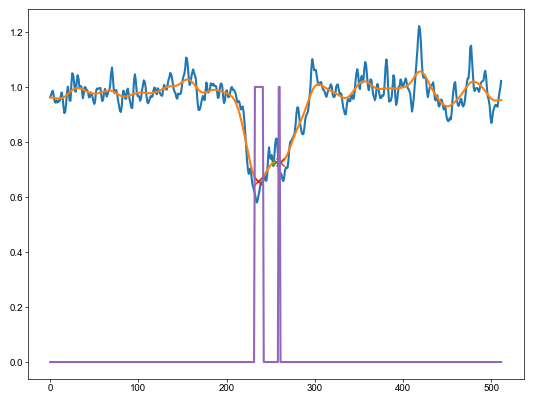

[230 285]


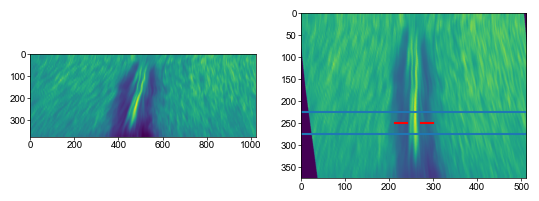

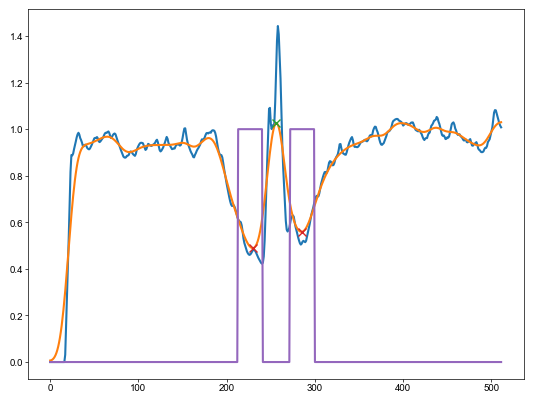

[223 270]


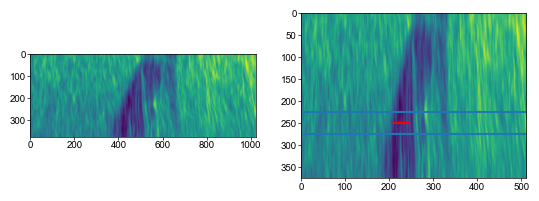

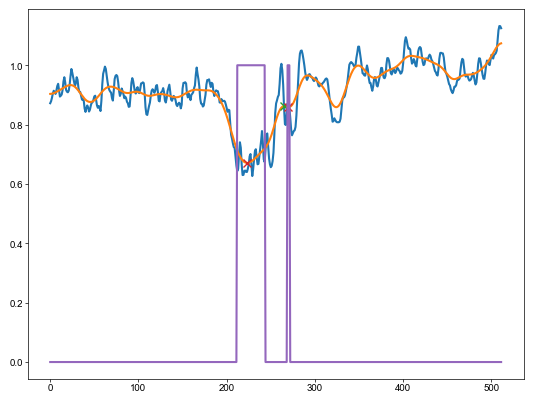

[230 286]


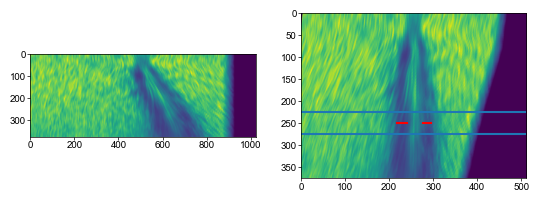

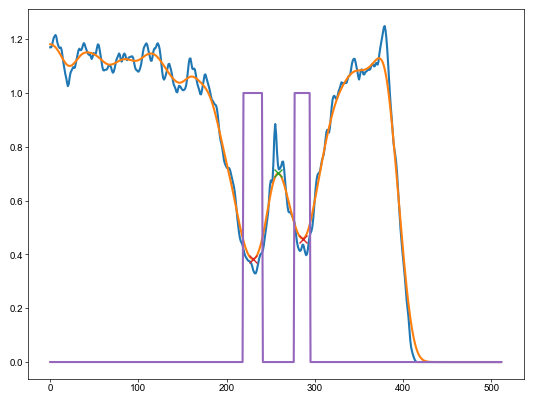

[229 282]


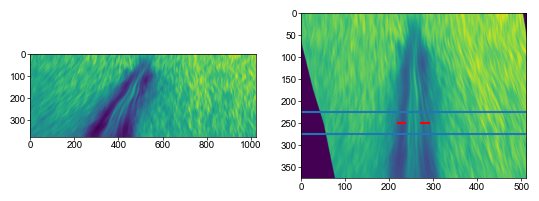

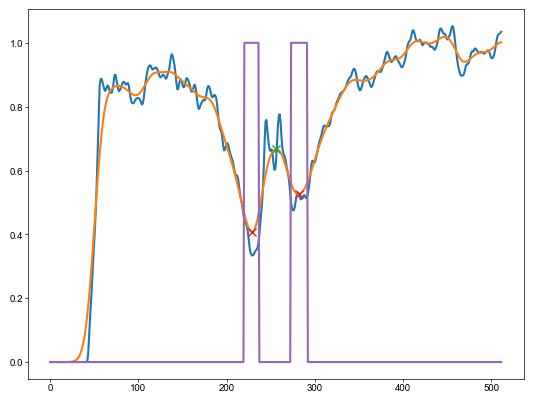

[223 278]


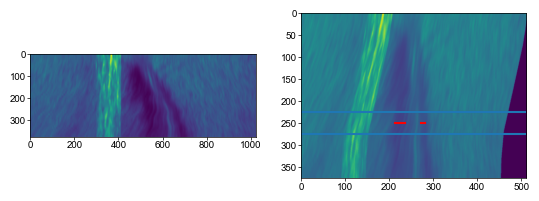

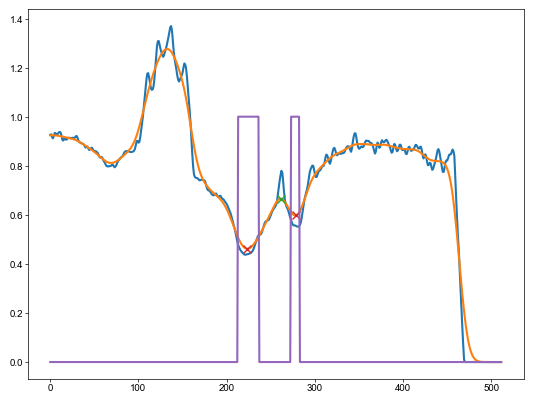

[229 281]


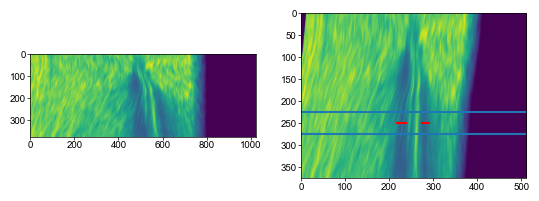

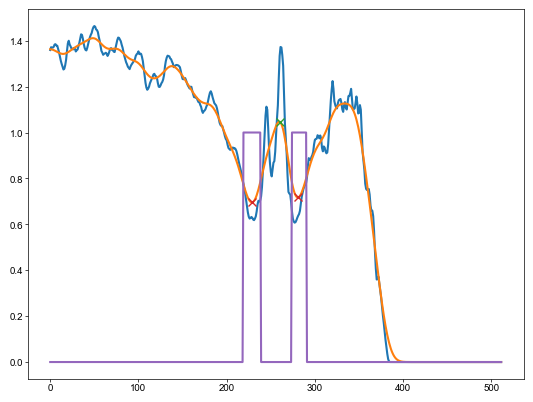

[224 272]


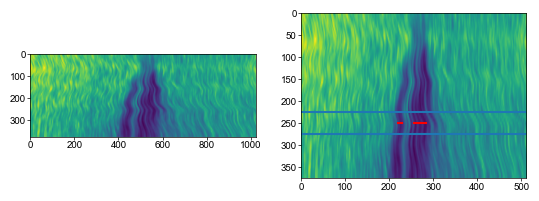

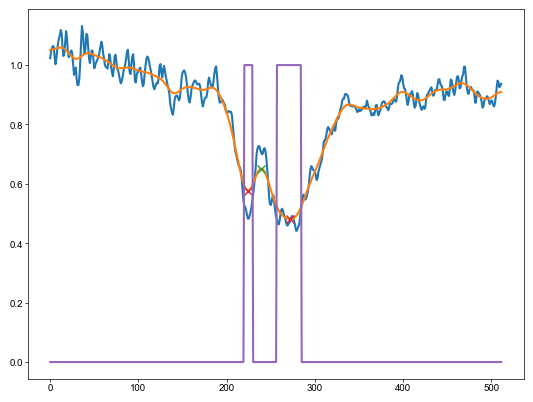

[238 281]


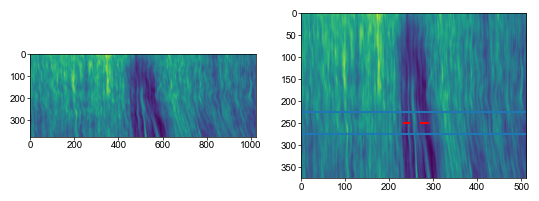

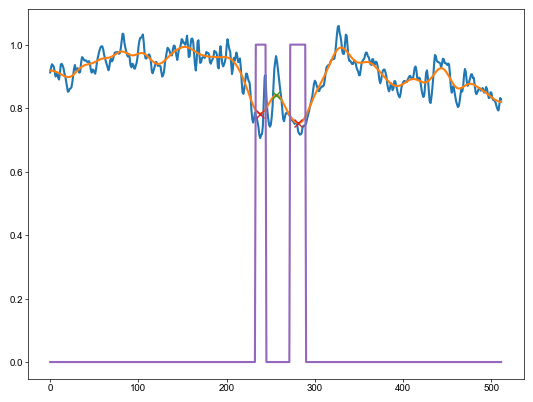

[246 292]


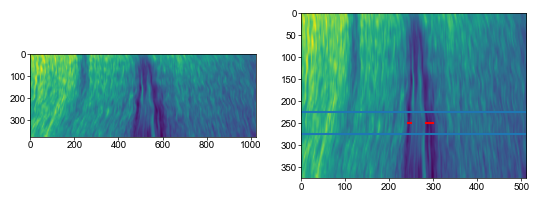

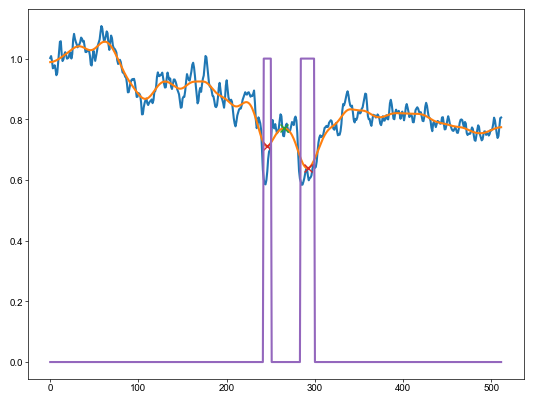

In [151]:
for i in range(rep_num):
# for i in range(2):
    image = images[i]
    fs, xs = image.shape
    correction = images_correction[i]
    if np.any(correction==255):
        new_image = np.zeros_like(image)
        for f in range(fs):
            center = np.where(correction[f]==255)[0][0]
            # print(center)
            if center>512:
                new_image[f, 0:1024-(center-512)] = image[f, center-512:1024]
            else:
                new_image[f, 512-center:1024] = image[f, 0:1024-(512-center)]
    else:
        new_image=image

    new_image = skimage.transform.rescale(new_image, (1,0.5))
    new_image /= np.nanmean(new_image[0])
    # new_image = new_image[:, ]

    range_to_average = np.array([450/2,550/2]).astype(int)

    intensity_profile = np.nanmean(new_image[range_to_average[0]:range_to_average[1]], axis=0)
    intensity_profile_1 = scipy.ndimage.gaussian_filter(intensity_profile, sigma=7.5)
    peaks, _ = scipy.signal.find_peaks(intensity_profile_1)
    peak = peaks[find_closest(peaks, 1024*0.5/2)[1]]
    troughs, _ = scipy.signal.find_peaks(-intensity_profile_1)
    troughs = find_closest_two(troughs, peak)[0]
    troughs = np.sort(troughs)
    print(troughs)

    # thresh1, thresh2 = (intensity_profile_1[peak] + )/2
    frac= .25
    thresh1, thresh2 = (intensity_profile_1[peak] - intensity_profile_1[troughs]) *frac + intensity_profile_1[troughs]
    
    mask1 =     intensity_profile_1 < thresh1
    mask1 = skimage.morphology.label(mask1)
    a = mask1[troughs[0]]
    mask1 = mask1==a
    adzwidth1 = np.sum(mask1)

    mask2 =     intensity_profile_1 < thresh2
    mask2 = skimage.morphology.label(mask2)
    a = mask2[troughs[1]]
    mask2 = mask2==a
    adzwidth2 = np.sum(mask2)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(image)
    axs[1].imshow(new_image)
    axs[1].axhline(y = range_to_average[0])
    axs[1].axhline(y = range_to_average[1])
    axs[1].plot(np.where(mask1)[0][[0, -1]], [np.mean(range_to_average)]*2, color='red')
    axs[1].plot(np.where(mask2)[0][[0, -1]], [np.mean(range_to_average)]*2, color='red')
    plt.show()

    fig,ax = plt.subplots()
    ax.plot(intensity_profile)
    ax.plot(intensity_profile_1)
    ax.plot(peak, intensity_profile_1[peak], 'x')
    ax.plot(troughs, intensity_profile_1[troughs], 'x')
    ax.plot(mask1 + mask2)
    plt.show()

    pixel_size = carhoa_data_info.loc[i, 'pixel_size']


    carhoa_data_info.loc[i, 'adz_width_2'] = (adzwidth1 + adzwidth2)/2 * (pixel_size*2)

### plot

In [152]:
# replcate the wt_data idx=3 with the manually measured one
wt_data_info.loc[3, 'adz_width_2'] = wt_data_info.loc[3, 'adz_width']


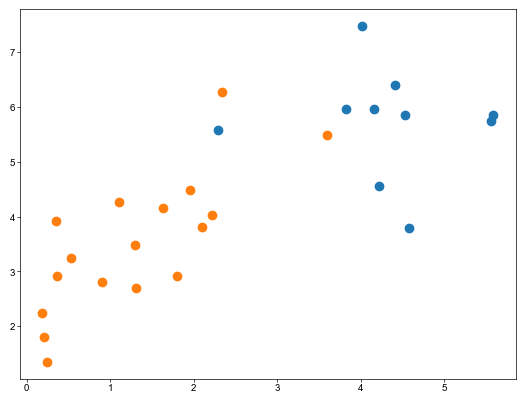

In [153]:
plt.scatter(wt_data_info['surrounding_cortex_flow'], wt_data_info['adz_width_2'])
plt.scatter(carhoa_data_info['surrounding_cortex_flow'], carhoa_data_info['adz_width_2'])

## Plot them

In [154]:
df = pd.concat([wt_data_info, carhoa_data_info], ignore_index=True)

In [155]:
df_to_excel = df[['cortex_flow_analysis', 'rep_name', 'file_name', 'cable_compression_flow', 'cable_qxx', 'surrounding_cortex_flow', 'adz_width']]
df_to_excel.rename(columns={'cortex_flow_analysis': 'Embryo type',
                            'rep_name': 'Replicate#',
                            'cable_compression_flow': 'Compression rate (/min, 43.5 mpf)',
                            'cable_qxx': 'Nematic order of actin cable (Q_yy, 47.5 mpf)',
                            'surrounding_cortex_flow': 'Diverging velocity (um/min, 47.5 mpf)',
                            'adz_width': 'Depletion zone width (um, 47.5 mpf)'}, inplace=True)

df_to_excel.to_excel('wt_and_carhoa-flow_analysis_excel_fig5d_figs6.xlsx', index=False)
# df_to_excel

### individual quantities

#### compression rate

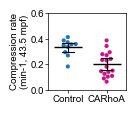

Shapiro p-values: 0.484, 0.220 → normal
Levene p-value: 0.105 → equal variance

Student's t-test: stat=-3.880, p=0.0007


In [156]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='cable_compression_flow', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='cable_compression_flow',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 0.6)
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Compression rate\n(min-1, 43.5 mpf)')
plt.savefig('ctrl-carhoa_compression_rate.svg')
plt.show()

groups = [grp['cable_compression_flow'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

#### nematic order

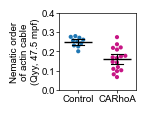

Shapiro p-values: 0.839, 0.632 → normal
Levene p-value: 0.016 → unequal variance

Welch's t-test: stat=-5.505, p=0.0000128346


In [157]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='cable_qxx', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='cable_qxx',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 0.4)
ax.set_yticks(np.arange(0, 0.5, 0.1))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Nematic order\nof actin cable\n(Qyy, 47.5 mpf)')
plt.savefig('ctrl-carhoa_nematic_order.svg')
plt.show()

groups = [grp['cable_qxx'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

In [158]:
potential_qxx_values = df.groupby('cortex_flow_analysis')['cable_qxx'].mean()
display(potential_qxx_values)

potential_qxx_ratio = potential_qxx_values[0] / potential_qxx_values[1]
print(potential_qxx_ratio)

cortex_flow_analysis
carhoa    0.159038
wt        0.249228
Name: cable_qxx, dtype: float64

0.6381213887599999


#### outward flow

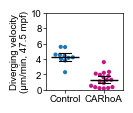

Shapiro p-values: 0.148, 0.203 → normal
Levene p-value: 0.515 → equal variance

Student's t-test: stat=-7.963, p=0.0000000255


In [159]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='surrounding_cortex_flow', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='surrounding_cortex_flow',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0, 11, 2))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Diverging velocity\n(\u03BCm/min, 47.5 mpf)')
plt.savefig('ctrl-carhoa_diverging velocity.svg')

plt.show()

groups = [grp['surrounding_cortex_flow'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

#### adz width_1

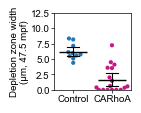

Shapiro p-values: 0.001, 0.320 → not normal
Levene p-value: 0.349 → equal variance

Mann-Whitney U: stat=9.000, p=0.0001382703


In [160]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='adz_width', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='adz_width',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 12.5)
ax.set_yticks(np.arange(0, 15, 2.5))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Depletion zone width\n(\u03BCm, 47.5 mpf)')
plt.savefig('ctrl-carhoa_adz_width.svg')

plt.show()


groups = [grp['adz_width'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

#### adz width 2

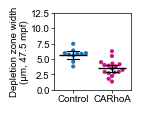

Shapiro p-values: 0.923, 0.278 → normal
Levene p-value: 0.251 → equal variance

Student's t-test: stat=-4.717, p=0.0000776570


In [161]:
fig,ax=plt.subplots(figsize=[1, 1])
sns.swarmplot(data = df, x = 'cortex_flow_analysis', y ='adz_width_2', ax = ax, size=3, hue = 'cortex_flow_analysis', legend=False, 
              order = ['wt', 'carhoa'], palette = ['tab:blue', 'mediumvioletred'])
sns.pointplot(data = df, x = 'cortex_flow_analysis', y ='adz_width_2',
              color='black', ax=ax, zorder=100,
              estimator='mean', errorbar=('ci', 95),
              linestyle='none', marker="_", markersize=20, markeredgewidth=1,
              capsize=0.3, err_kws={'linewidth': 0.8})
ax.set_ylim(0, 12.5)
ax.set_yticks(np.arange(0, 15, 2.5))
ax.set_xticklabels(['Control', 'CARhoA'])
ax.set_xlabel('')
ax.set_ylabel('Depletion zone width\n(\u03BCm, 47.5 mpf)')
plt.savefig('ctrl-carhoa_adz_width_2.svg')

plt.show()


groups = [grp['adz_width_2'].dropna().values for _, grp in df.groupby('cortex_flow_analysis')]
assert len(groups) == 2, "Expected exactly 2 categories in A"
g1, g2 = groups

# 1. Normality (Shapiro-Wilk)
_, p_norm1 = scipy.stats.shapiro(g1)
_, p_norm2 = scipy.stats.shapiro(g2)
normal = p_norm1 > 0.05 and p_norm2 > 0.05
print(f"Shapiro p-values: {p_norm1:.3f}, {p_norm2:.3f} → {'normal' if normal else 'not normal'}")

# 2. Equal variance
if normal:
    _, p_var = scipy.stats.levene(g1, g2)
else:
    _, p_var = scipy.stats.levene(g1, g2)  # Levene is robust to non-normality too
equal_var = p_var > 0.05
print(f"Levene p-value: {p_var:.3f} → {'equal variance' if equal_var else 'unequal variance'}")

# 3. Test
if normal:
    stat, p = scipy.stats.ttest_ind(g1, g2, equal_var=equal_var)
    test_name = "Student's t-test" if equal_var else "Welch's t-test"
else:
    stat, p = scipy.stats.mannwhitneyu(g1, g2, alternative='two-sided')
    test_name = "Mann-Whitney U"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.10f}")

### correlations

#### normalize

In [162]:
wt_data_info['adz_width_2_norm'] = wt_data_info['adz_width_2']/(wt_data_info['adz_width_2'].mean())
carhoa_data_info['adz_width_2_norm'] = carhoa_data_info['adz_width_2']/(wt_data_info['adz_width_2'].mean())

wt_data_info['surrounding_cortex_flow_norm'] = wt_data_info['surrounding_cortex_flow']/(wt_data_info['surrounding_cortex_flow'].mean())
carhoa_data_info['surrounding_cortex_flow_norm'] = carhoa_data_info['surrounding_cortex_flow']/(wt_data_info['surrounding_cortex_flow'].mean())

wt_data_info['cable_qxx_norm'] = wt_data_info['cable_qxx']/(wt_data_info['cable_qxx'].mean())
carhoa_data_info['cable_qxx_norm'] = carhoa_data_info['cable_qxx']/(wt_data_info['cable_qxx'].mean())

np.savez("cable_nematic_order_wt_vs_carhoa.npz",
         wt = wt_data_info['cable_qxx_norm'],
         carhoa = carhoa_data_info['cable_qxx_norm'])

In [163]:
simulations = np.load('simulations_yil//caRhoA_20260610.npz')
simulations

NpzFile 'simulations_yil//caRhoA_20260610.npz' with keys: velocities, widths, param_sets, nematic

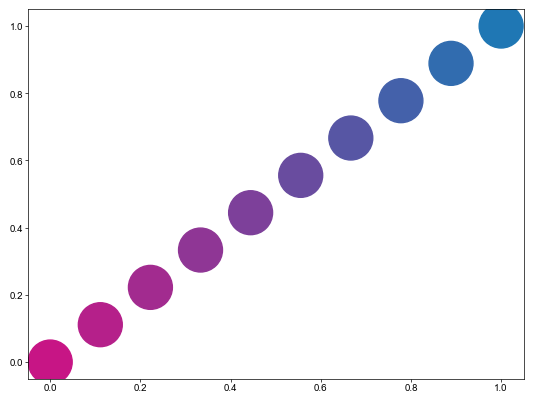

In [164]:
# create a new colormap

from matplotlib.colors import LinearSegmentedColormap
from xint_toolbox import colored_line

def two_color_colormap(color1, color2, name="custom_cmap"):
    """
    Create a linear colormap between two colors.

    Parameters:
        color1 (str or tuple): First color (e.g., "blue" or (0.1, 0.2, 0.5)).
        color2 (str or tuple): Second color (e.g., "red" or (0.8, 0.2, 0.3)).
        name (str): Name of the colormap.

    Returns:
        LinearSegmentedColormap: A matplotlib colormap object.
    """
    return LinearSegmentedColormap.from_list(name, [color1, color2])

# Example usage
tabblue_mediumvioletred_cmap = two_color_colormap("tab:blue", "mediumvioletred")
mediumvioletred_tabblue_cmap = two_color_colormap("mediumvioletred", "tab:blue")

# Plot an example gradient
import numpy as np
gradient = np.linspace(0, 1, 10)
plt.scatter(gradient, gradient, c=mediumvioletred_tabblue_cmap(gradient), s=1000)
plt.show()


In [165]:
simulations['param_sets']

array([1.1 , 1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55])

#### outward flow ~ qxx

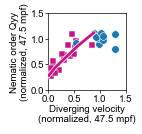

In [166]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_cable_qxx_wt, sim_cable_qxx_lowerchi = simulations['nematic']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1,1 ])

sim_param_threshs = 0.9, 1
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param>=sim_param_threshs[0]], 'tab:blue', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param<=sim_param_threshs[0]], sim_cable_qxx_wt[sim_param<=sim_param_threshs[0]], 'tab:blue', ls=':', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param<=sim_param_threshs[1]], 'mediumvioletred', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param>=sim_param_threshs[1]], sim_cable_qxx_lowerchi[sim_param>=sim_param_threshs[1]], 'mediumvioletred', ls=':', lw=2, zorder=10)

ax.plot(sim_surrounding_cortex_flow_lowerchi, sim_cable_qxx_lowerchi, 'white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi, sim_cable_qxx_lowerchi, 'mediumvioletred', ls='-', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1, zorder=5)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='cable_qxx_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1, zorder=5)

ax.set_xlim(0, 1.5)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
# ax.set_yticks(np.arange(0, 1)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Nematic order Qyy\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-no_insilico.svg')
plt.show()

#### outward flow ~ adz width

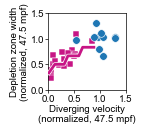

In [169]:
sim_surrounding_cortex_flow_wt, sim_surrounding_cortex_flow_lowerchi = simulations['velocities']
sim_adz_width_wt, sim_adz_width_lowerchi = simulations['widths']
sim_param = simulations['param_sets']

fig,ax=plt.subplots(figsize=[1, 1])

sim_param_threshs = 0.9, 1
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='white', ls='-', lw=3, zorder=9)
# ax.plot(sim_surrounding_cortex_flow_wt[sim_param>=sim_param_threshs[0]], sim_adz_width_wt[sim_param>=sim_param_threshs[0]], color='tab:blue', ls='-', lw=2, zorder=10)
# ax.plot(sim_surrounding_cortex_flow_lowerchi[sim_param<=sim_param_threshs[1]], sim_adz_width_lowerchi[sim_param<=sim_param_threshs[1]], color='mediumvioletred', ls='-', lw=2, zorder=10)

ax.plot(sim_surrounding_cortex_flow_lowerchi, sim_adz_width_lowerchi, color='white', ls='-', lw=3, zorder=9)
ax.plot(sim_surrounding_cortex_flow_lowerchi, sim_adz_width_lowerchi, color='mediumvioletred', ls='-', lw=2, zorder=10)


sns.scatterplot(data=carhoa_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_2_norm', color='mediumvioletred', marker = 's',  s=20,
                ax=ax, alpha=1)
sns.scatterplot(data=wt_data_info, legend=False,
                x='surrounding_cortex_flow_norm', y='adz_width_2_norm', color='tab:blue', marker = 'o', s=30,
                ax=ax, alpha=1)

ax.set_xlim(0, 1.5)
ax.set_xticks(np.arange(0, 2, 0.5)) 
ax.set_ylim(0, 1.5)
ax.set_yticks(np.arange(0, 2, 0.5)) 
ax.set_xlabel('Diverging velocity\n(normalized, 47.5 mpf)', fontsize=7)
ax.set_ylabel('Depletion zone width\n(normalized, 47.5 mpf)', fontsize=7)

# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=7)
plt.savefig('diverging-adz-width_insilico.svg')
plt.show()

In [180]:
df_to_export1 = carhoa_data_info[['cortex_flow_analysis', 'cable_compression_flow', 'surrounding_cortex_flow', 'cable_qxx', 'adz_width_2', 'rep_name', 'file_name', 'embryo']]
df_to_export2 = wt_data_info[['cortex_flow_analysis', 'cable_compression_flow', 'surrounding_cortex_flow', 'cable_qxx', 'adz_width_2', 'rep_name', 'file_name', 'embryo']]
df_to_export = pd.concat([df_to_export1, df_to_export2])

df_to_export.columns = ['Type', 'Compression rate at 43.5 mpf (min^-1)', 'Diverging velocity at 47.5 mpf (um/min)', 'Nematic order Q_yy at 47.5 mpf', 'Depletion zone width at 47.5 mpf (um)', 'Replicate number', 'Experiment date', 'Embryo number']
df_to_export.to_excel('wt_and_carhoa-flow_analysis_excel_figs6BCDE.xlsx', index=False)
df_to_export

,Type,Compression rate at 43.5 mpf (min^-1),Diverging velocity at 47.5 mpf (um/min),Nematic order Q_yy at 47.5 mpf,Depletion zone width at 47.5 mpf (um),Replicate number,Experiment date,Embryo number
0,carhoa,0.145,1.804838,0.165414,2.915006,rep56,xin240816,e45
1,carhoa,0.103,0.210881,0.066235,1.793850,rep67,xin240802_csu3_utregfp_carhoa600nginj,e22
2,carhoa,0.064,0.183783,0.101778,2.242312,rep68,xin240802_csu3_utregfp_carhoa600nginj,e23
3,carhoa,0.342,3.600947,0.220294,5.493664,rep72,xin240725_csu1_lifeact_carhoa600pginj,e022
4,carhoa,0.140,0.357478,0.118158,2.915006,rep76,xin240724_csu3_utregfp_carhoa600nginj,e017
5,carhoa,0.089,0.902940,0.096994,2.802890,rep77,xin240724_csu3_utregfp_carhoa600nginj,e018
6,carhoa,0.125,1.295968,0.168937,3.475584,rep80,xin240723_csu3_utregfp_carhoa600nginj,e015
7,carhoa,0.109,0.237330,0.109030,1.345387,rep81,xin240723_csu3_utregfp_carhoa600nginj,e016
8,carhoa,0.229,2.338044,0.236708,6.278474,rep82,xin240710_csu3_utregfp_carhoa600ng_e1,e12
9,carhoa,0.233,0.347221,0.142158,3.924046,rep83,xin240710_csu3_utregfp_carhoa600ng_e1,e13


In [185]:
df_to_export1 = carhoa_data_info[['cortex_flow_analysis', 'surrounding_cortex_flow_norm', 'cable_qxx_norm', 'adz_width_2_norm', 'rep_name', 'file_name', 'embryo']]
df_to_export2 = wt_data_info[['cortex_flow_analysis', 'surrounding_cortex_flow_norm', 'cable_qxx_norm', 'adz_width_2_norm', 'rep_name', 'file_name', 'embryo']]
df_to_export = pd.concat([df_to_export1, df_to_export2])

df_to_export.columns = ['Type', 'Diverging velocity at 47.5 mpf (normalized)', 'Nematic order Q_yy at 47.5 mpf (normalized)', 'Depletion zone width at 47.5 mpf (normalized)', 'Replicate number', 'Experiment date', 'Embryo number']
df_to_export.to_excel('wt_and_carhoa-flow_analysis_excel_fig5d.xlsx', index=False)
df_to_export

# See Supplementary Note 1 and https://github.com/Irene-Li/Zebrafish_cleavage for more information of the overlaid simulation values

,Type,Diverging velocity at 47.5 mpf (normalized),Nematic order Q_yy at 47.5 mpf (normalized),Depletion zone width at 47.5 mpf (normalized),Replicate number,Experiment date,Embryo number
0,carhoa,0.418123,0.663706,0.510100,rep56,xin240816,e45
1,carhoa,0.048854,0.265762,0.313907,rep67,xin240802_csu3_utregfp_carhoa600nginj,e22
2,carhoa,0.042577,0.408373,0.392384,rep68,xin240802_csu3_utregfp_carhoa600nginj,e23
3,carhoa,0.834223,0.883902,0.961341,rep72,xin240725_csu1_lifeact_carhoa600pginj,e022
4,carhoa,0.082816,0.474094,0.510100,rep76,xin240724_csu3_utregfp_carhoa600nginj,e017
5,carhoa,0.209182,0.389178,0.490480,rep77,xin240724_csu3_utregfp_carhoa600nginj,e018
6,carhoa,0.300234,0.677841,0.608196,rep80,xin240723_csu3_utregfp_carhoa600nginj,e015
7,carhoa,0.054982,0.437471,0.235431,rep81,xin240723_csu3_utregfp_carhoa600nginj,e016
8,carhoa,0.541649,0.949763,1.098676,rep82,xin240710_csu3_utregfp_carhoa600ng_e1,e12
9,carhoa,0.080440,0.570391,0.686672,rep83,xin240710_csu3_utregfp_carhoa600ng_e1,e13
